In [1]:
import pickle
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
with open("/scratch/gpfs/LYDIALYNCH/rc2020/SC_out/QC/Miceimmune_parts.pkl", "rb") as f:
    payload = pickle.load(f)

adata_immune = ad.AnnData(
    X=payload["X"],
    obs=payload["obs"],
    var=payload["var"],
)

adata_immune.uns = payload["uns"]
adata_immune.obsm = payload["obsm"]
adata_immune.varm = payload["varm"]
adata_immune.layers = payload["layers"]

if "raw_X" in payload:
    adata_immune.raw = ad.AnnData(
        X=payload["raw_X"],
        var=payload["raw_var"]
    )

/tmp/ipykernel_231181/146726917.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  payload = pickle.load(f)


In [3]:
with open("/scratch/gpfs/LYDIALYNCH/rc2020/SC_out/QC/Micefap_parts.pkl", "rb") as f:
    payload = pickle.load(f)

adata_fap = ad.AnnData(
    X=payload["X"],
    obs=payload["obs"],
    var=payload["var"],
)

adata_fap.uns = payload["uns"]
adata_fap.obsm = payload["obsm"]
adata_fap.varm = payload["varm"]
adata_fap.layers = payload["layers"]

if "raw_X" in payload:
    adata_fap.raw = ad.AnnData(
        X=payload["raw_X"],
        var=payload["raw_var"]
    )

/tmp/ipykernel_231181/3615937251.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  payload = pickle.load(f)


In [4]:
adata_fap.obs

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,low_n_genes,high_mt,high_counts,doublet_score,predicted_doublet,mouse_id,condition,leiden,celltype,IPC_SkM,FAP_Cxcl14,FAP_Prg4,FAP_CD142,FAP_post_injury,MAB,Sca1_high
AAACCCAAGATCCAAA-1-Mice1,2852,7489.0,248.0,3.311523,False,False,False,0.014628,False,Mouse1,sedentary,7,IPC_Skm,2.107124,-1.370011,-1.370011,-1.370011,0.452914,-0.094144,1.066186
AAACCCACACATTCGA-1-Mice1,3306,10321.0,122.0,1.182056,False,False,False,0.014628,False,Mouse1,sedentary,1,IPC_Skm,1.060668,-1.499438,-1.499438,-1.499438,0.207381,-0.076190,1.049883
AAACCCACACTCGATA-1-Mice1,3255,8872.0,226.0,2.547340,False,False,False,0.018552,False,Mouse1,sedentary,8,Prg4+,-0.188034,-1.490463,1.675880,-0.370250,-0.624965,-0.162642,-0.781072
AAACCCACAGCGTTGC-1-Mice1,2847,7568.0,146.0,1.929175,False,False,False,0.041667,False,Mouse1,sedentary,0,Prg4+,-0.515307,0.349956,0.349956,-1.423350,-0.615187,-0.120579,1.473447
AAACCCACATCGTGCG-1-Mice1,3579,12396.0,220.0,1.774766,False,False,False,0.106838,False,Mouse1,sedentary,2,Cxcl14+,-0.941267,2.755263,-1.472333,0.113286,-0.444103,-0.083460,0.260874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGATCAGAGGACTC-1-Mice7,3576,13133.0,334.0,2.543212,False,False,False,0.068301,False,Mouse7,exercise,5,CD142+,-0.840877,1.970439,-1.312498,-0.796623,0.246555,-0.092858,0.735329
TTTGGAGTCTCCCTAG-1-Mice7,3385,12394.0,198.0,1.597547,False,False,False,0.035755,False,Mouse7,exercise,0,Prg4+,-0.889979,-1.477614,2.594921,-0.923835,-0.687584,-0.055378,0.343495
TTTGGTTGTCGTCAGC-1-Mice7,3840,13012.0,449.0,3.450661,False,False,False,0.048679,False,Mouse7,exercise,7,IPC_Skm,0.334346,-1.267461,1.873036,-0.742079,-0.104085,-0.069899,2.179622
TTTGGTTTCTTTCCGG-1-Mice7,4163,16855.0,297.0,1.762088,False,False,False,0.113990,False,Mouse7,exercise,9,Cxcl14+,-0.850125,3.069768,-1.454636,0.138332,1.467538,1.237717,-0.703446


In [6]:
adata_immune = adata_immune.copy()

In [7]:
adata_fap = adata_fap.copy()

In [8]:
adata_immune.obs

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,low_n_genes,high_mt,high_counts,doublet_score,predicted_doublet,mouse_id,condition,leiden,celltype
AAAGGGCAGCAAGTCG-1-Mice1,1644,3548.0,170.0,4.791432,False,False,False,0.047733,False,Mouse1,sedentary,2,B_Cell
AAAGGTAGTAACAGTA-1-Mice1,1551,2748.0,148.0,5.385735,False,False,False,0.054974,False,Mouse1,sedentary,7,ILC2
AAAGTGATCACTTTGT-1-Mice1,765,1489.0,32.0,2.149093,False,False,False,0.227642,False,Mouse1,sedentary,10,Mast_cell
AAAGTGATCTCAAAGC-1-Mice1,1592,3200.0,200.0,6.250000,False,False,False,0.074675,False,Mouse1,sedentary,6,Macrophages
AACCAACGTCCCTAAA-1-Mice1,1818,3536.0,98.0,2.771493,False,False,False,0.017947,False,Mouse1,sedentary,0,NK_cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGACCCTCAGGACGA-1-Mice7,2460,21892.0,320.0,1.461721,False,False,False,0.062500,False,Mouse7,exercise,1,Neutrophils
TTGGGCGAGGCTTAAA-1-Mice7,3110,10570.0,568.0,5.373699,False,False,False,0.128940,False,Mouse7,exercise,6,Macrophages
TTTACTGGTACGATTC-1-Mice7,2229,5686.0,234.0,4.115371,False,False,False,0.201681,False,Mouse7,exercise,2,B_Cell
TTTAGTCTCTAGCCAA-1-Mice7,2061,11514.0,582.0,5.054716,False,False,False,0.022957,False,Mouse7,exercise,1,Neutrophils


In [9]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import liana as li

# -----------------------------
# 1. Keep only shared genes
# -----------------------------
shared_genes = adata_fap.var_names.intersection(adata_immune.var_names)

adata_fap_sub = adata_fap[:, shared_genes].copy()
adata_immune_sub = adata_immune[:, shared_genes].copy()

# -----------------------------
# 2. Make sure celltype + condition columns exist
# -----------------------------
for adata_obj in [adata_fap_sub, adata_immune_sub]:
    if "celltype" not in adata_obj.obs.columns:
        raise ValueError("Need a 'celltype' column in .obs")
    if "condition" not in adata_obj.obs.columns:
        raise ValueError("Need a 'condition' column in .obs")

# Optional: add source label
adata_fap_sub.obs["compartment"] = "FAP"
adata_immune_sub.obs["compartment"] = "Immune"

# -----------------------------
# 3. Concatenate into one object
# -----------------------------
adata_combined = ad.concat(
    [adata_fap_sub, adata_immune_sub],
    join="inner",
    label="dataset",
    keys=["fap", "immune"],
    merge="same"
)

# Make sure celltype is categorical
adata_combined.obs["celltype"] = adata_combined.obs["celltype"].astype("category")
adata_combined.obs["condition"] = adata_combined.obs["condition"].astype("category")

print(adata_combined)
print(adata_combined.obs["celltype"].value_counts())

AnnData object with n_obs × n_vars = 29332 × 19733
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'low_n_genes', 'high_mt', 'high_counts', 'doublet_score', 'predicted_doublet', 'mouse_id', 'condition', 'leiden', 'celltype', 'compartment', 'dataset'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts-Mice1', 'mean_counts-Mice1', 'pct_dropout_by_counts-Mice1', 'total_counts-Mice1', 'n_cells_by_counts-Mice2', 'mean_counts-Mice2', 'pct_dropout_by_counts-Mice2', 'total_counts-Mice2', 'n_cells_by_counts-Mice3', 'mean_counts-Mice3', 'pct_dropout_by_counts-Mice3', 'total_counts-Mice3', 'n_cells_by_counts-Mice4', 'mean_counts-Mice4', 'pct_dropout_by_counts-Mice4', 'total_counts-Mice4', 'n_cells_by_counts-Mice5', 'mean_counts-Mice5', 'pct_dropout_by_counts-Mice5', 'total_counts-Mice5', 'n_cells_by_counts-Mice6', 'mean_counts-Mice6', 'pct_dropout_by_counts-Mice6', 'total_counts-Mice6', 'n_cells_by_counts-Mice7', 'mean_counts-Mice7', 'pct_dropout_by_co

In [10]:
import liana as li

li.mt.cellphonedb(
    adata_combined,
    groupby="celltype",
    resource_name="mouseconsensus",
    expr_prop=0.1,
    use_raw=False,
    n_perms=1000
)

/home/rc2020/miniconda3/envs/liana_only/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/rc2020/miniconda3/envs/liana_only/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


In [11]:
res = adata_combined.uns["liana_res"]
res.head()

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
26977,Dcn,Dcn,5.838828,1.0,Egfr,Egfr,2.064701,0.907720,Sca1-,FAP,3.951764,0.0
21094,Dcn,Dcn,5.838828,1.0,Egfr,Egfr,1.903032,0.971693,Sca1-,Cxcl14+,3.870930,0.0
37073,Dcn,Dcn,5.838828,1.0,Egfr,Egfr,1.721730,0.960689,Sca1-,IPC_Skm,3.780279,0.0
14462,Dcn,Dcn,5.838828,1.0,Egfr,Egfr,1.583320,0.907876,Sca1-,CD142+,3.711074,0.0
23238,Dcn,Dcn,5.294572,1.0,Egfr,Egfr,2.064701,0.907720,Cxcl14+,FAP,3.679636,0.0


In [12]:
res[
    (res["ligand"] == "Il33") &
    (res["target"] == "ILC2")
].sort_values("lr_means", ascending=False)

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
30408,Il33,Il33,1.200086,0.732932,Il1rap,Il1rap_Il1rl1,0.039195,0.166667,Sca1-,ILC2,0.619640,0.000
29131,Il33,Il33,0.769797,0.667447,Il1rap,Il1rap_Il1rl1,0.039195,0.166667,IPC_Skm,ILC2,0.404496,0.317
28346,Il33,Il33,0.768771,0.629858,Il1rap,Il1rap_Il1rl1,0.039195,0.166667,Cxcl14+,ILC2,0.403983,0.330
28011,Il33,Il33,0.419453,0.404263,Il1rap,Il1rap_Il1rl1,0.039195,0.166667,CD142+,ILC2,0.229324,1.000
28675,Il33,Il33,0.412612,0.290109,Il1rap,Il1rap_Il1rl1,0.039195,0.166667,FAP,ILC2,0.225903,1.000
30062,Il33,Il33,0.173766,0.192561,Il1rap,Il1rap_Il1rl1,0.039195,0.166667,Prg4+,ILC2,0.106480,1.000


In [13]:
res[
    (res["ligand"] == "Il15") &
    (res["target"] == "ILC2")
].sort_values("lr_means", ascending=False)

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
29877,Il15,Il15,0.338791,0.783505,Il2ra,Il2ra,0.270683,0.859649,Neutrophils,ILC2,0.304737,0.000
29640,Il15,Il15,0.198546,0.533333,Il2ra,Il2ra,0.270683,0.859649,Mast_cell,ILC2,0.234614,0.004
28418,Il15,Il15,0.197359,0.238416,Il2ra,Il2ra,0.270683,0.859649,Cxcl14+,ILC2,0.234021,0.000
28745,Il15,Il15,0.140740,0.112183,Il2ra,Il2ra,0.270683,0.859649,FAP,ILC2,0.205711,0.000
29202,Il15,Il15,0.107610,0.167949,Il2ra,Il2ra,0.270683,0.859649,IPC_Skm,ILC2,0.189146,0.000
29874,Il15,Il15,0.338791,0.783505,Il15ra,Il15ra_Il2rb_Il2rg,0.032937,0.122807,Neutrophils,ILC2,0.185864,0.166
30136,Il15,Il15,0.096808,0.134429,Il2ra,Il2ra,0.270683,0.859649,Prg4+,ILC2,0.183745,0.000
28080,Il15,Il15,0.084403,0.120665,Il2ra,Il2ra,0.270683,0.859649,CD142+,ILC2,0.177543,0.000
29468,Il15,Il15,0.041803,0.204255,Il2ra,Il2ra,0.270683,0.859649,Macrophages,ILC2,0.156243,0.000
29637,Il15,Il15,0.198546,0.533333,Il15ra,Il15ra_Il2rb_Il2rg,0.032937,0.122807,Mast_cell,ILC2,0.115742,0.881


In [14]:
res[
    (res["ligand"] == "Il15") &
    (res["target"] == "NK_cell")
].sort_values("lr_means", ascending=False)

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, fisher_exact
from statsmodels.stats.multitest import multipletests

# -----------------------------
# SETTINGS
# -----------------------------
adata = adata_immune.copy()   # use your immune AnnData
gene = "Il1rl1"               # IL-33 receptor (ST2)
ilc2_label = "ILC2"           # change if your celltype label is different
pos_thresh = 0.5              # threshold for calling a cell Il1rl1+

# -----------------------------
# CHECK GENE EXISTS
# -----------------------------
if gene not in adata.var_names:
    raise ValueError(f"{gene} not found in adata.var_names")

# -----------------------------
# EXTRACT ILC2 DATA
# -----------------------------
adata_ilc2 = adata[adata.obs["celltype"] == ilc2_label].copy()

x = adata_ilc2[:, gene].X
if hasattr(x, "toarray"):
    x = x.toarray().flatten()
else:
    x = np.array(x).flatten()

df_ilc2 = pd.DataFrame({
    gene: x,
    "condition": adata_ilc2.obs["condition"].values
})

# -----------------------------
# 1A. TEST EXPRESSION LEVEL
# -----------------------------
ex_expr = df_ilc2.loc[df_ilc2["condition"] == "exercise", gene]
sed_expr = df_ilc2.loc[df_ilc2["condition"] == "sedentary", gene]

expr_stat, expr_pval = mannwhitneyu(ex_expr, sed_expr, alternative="two-sided")

print(f"{gene} expression in ILC2")
print(f"Exercise mean:   {ex_expr.mean():.4f}")
print(f"Sedentary mean:  {sed_expr.mean():.4f}")
print(f"Mann-Whitney U p-value: {expr_pval:.4e}")

# -----------------------------
# 1B. TEST PROPORTION POSITIVE
# -----------------------------
df_ilc2[f"{gene}_pos"] = df_ilc2[gene] > pos_thresh

ex_pos = df_ilc2.loc[df_ilc2["condition"] == "exercise", f"{gene}_pos"]
sed_pos = df_ilc2.loc[df_ilc2["condition"] == "sedentary", f"{gene}_pos"]

table = np.array([
    [ex_pos.sum(), (~ex_pos).sum()],
    [sed_pos.sum(), (~sed_pos).sum()]
])

oddsratio, prop_pval = fisher_exact(table)

print(f"\n{gene}+ proportion in ILC2 (threshold > {pos_thresh})")
print(f"Exercise proportion:   {ex_pos.mean():.4f}")
print(f"Sedentary proportion:  {sed_pos.mean():.4f}")
print(f"Fisher's exact p-value: {prop_pval:.4e}")
print("Contingency table:")
print(table)

Il1rl1 expression in ILC2
Exercise mean:   0.2863
Sedentary mean:  0.3595
Mann-Whitney U p-value: 1.1658e-08

Il1rl1+ proportion in ILC2 (threshold > 0.5)
Exercise proportion:   0.0159
Sedentary proportion:  0.0980
Fisher's exact p-value: 8.7721e-02
Contingency table:
[[ 1 62]
 [ 5 46]]


Il1rl1 expression in ILC2
Exercise mean:   0.2863
Sedentary mean:  0.3595
Mann-Whitney U p-value: 1.1658e-08

Il1rl1+ proportion in ILC2 (threshold > 0.25)
Exercise proportion:   0.8571
Sedentary proportion:  0.9412
Fisher's exact p-value: 2.2055e-01
Contingency table:
[[54  9]
 [48  3]]


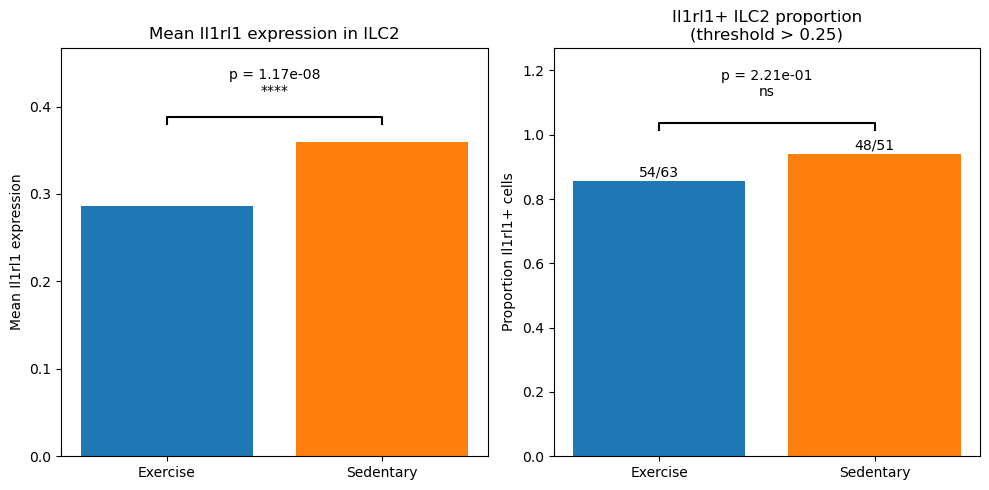

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, fisher_exact

# -----------------------------
# SETTINGS
# -----------------------------
adata = adata_immune.copy()   # use your immune AnnData
gene = "Il1rl1"               # IL-33 receptor (ST2)
ilc2_label = "ILC2"           # change if your celltype label is different
pos_thresh = 0.25              # threshold for calling a cell Il1rl1+

# -----------------------------
# CHECK GENE EXISTS
# -----------------------------
if gene not in adata.var_names:
    raise ValueError(f"{gene} not found in adata.var_names")

# -----------------------------
# EXTRACT ILC2 DATA
# -----------------------------
adata_ilc2 = adata[adata.obs["celltype"] == ilc2_label].copy()

x = adata_ilc2[:, gene].X
if hasattr(x, "toarray"):
    x = x.toarray().flatten()
else:
    x = np.array(x).flatten()

df_ilc2 = pd.DataFrame({
    gene: x,
    "condition": adata_ilc2.obs["condition"].values
})

# -----------------------------
# 1A. TEST EXPRESSION LEVEL
# -----------------------------
ex_expr = df_ilc2.loc[df_ilc2["condition"] == "exercise", gene]
sed_expr = df_ilc2.loc[df_ilc2["condition"] == "sedentary", gene]

expr_stat, expr_pval = mannwhitneyu(ex_expr, sed_expr, alternative="two-sided")

print(f"{gene} expression in ILC2")
print(f"Exercise mean:   {ex_expr.mean():.4f}")
print(f"Sedentary mean:  {sed_expr.mean():.4f}")
print(f"Mann-Whitney U p-value: {expr_pval:.4e}")

# -----------------------------
# 1B. TEST PROPORTION POSITIVE
# -----------------------------
df_ilc2[f"{gene}_pos"] = df_ilc2[gene] > pos_thresh

ex_pos = df_ilc2.loc[df_ilc2["condition"] == "exercise", f"{gene}_pos"]
sed_pos = df_ilc2.loc[df_ilc2["condition"] == "sedentary", f"{gene}_pos"]

table = np.array([
    [ex_pos.sum(), (~ex_pos).sum()],
    [sed_pos.sum(), (~sed_pos).sum()]
])

oddsratio, prop_pval = fisher_exact(table)

print(f"\n{gene}+ proportion in ILC2 (threshold > {pos_thresh})")
print(f"Exercise proportion:   {ex_pos.mean():.4f}")
print(f"Sedentary proportion:  {sed_pos.mean():.4f}")
print(f"Fisher's exact p-value: {prop_pval:.4e}")
print("Contingency table:")
print(table)

# -----------------------------
# HELPER: p-value to stars
# -----------------------------
def p_to_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# -----------------------------
# PREP DATA FOR BAR PLOTS
# -----------------------------
conditions = ["exercise", "sedentary"]
condition_labels = ["Exercise", "Sedentary"]

mean_vals = [ex_expr.mean(), sed_expr.mean()]
prop_vals = [ex_pos.mean(), sed_pos.mean()]

pos_counts = [ex_pos.sum(), sed_pos.sum()]
total_counts = [len(ex_pos), len(sed_pos)]
color_map = {
    "exercise": "#1f77b4",
    "sedentary": "#ff7f0e"
}

colors = [color_map[c] for c in conditions]
# -----------------------------
# PLOT
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ---- Panel 1: mean expression ----
axes[0].bar(condition_labels, mean_vals, color=colors)
axes[0].set_ylabel(f"Mean {gene} expression")
axes[0].set_title(f"Mean {gene} expression in ILC2")


ymax1 = max(mean_vals)
line_y1 = ymax1 * 1.08
text_y1 = ymax1 * 1.14

axes[0].plot([0, 0, 1, 1], [line_y1*0.98, line_y1, line_y1, line_y1*0.98], lw=1.5, c="black")
axes[0].text(
    0.5,
    text_y1,
    f"p = {expr_pval:.2e}\n{p_to_stars(expr_pval)}",
    ha="center",
    va="bottom",
    fontsize=10
)
axes[0].set_ylim(0, ymax1 * 1.3)

# ---- Panel 2: positive proportion ----
axes[1].bar(condition_labels, prop_vals, color=colors)
axes[1].set_ylabel(f"Proportion {gene}+ cells")
axes[1].set_title(f"{gene}+ ILC2 proportion\n(threshold > {pos_thresh})")

for i, (prop, pos, total) in enumerate(zip(prop_vals, pos_counts, total_counts)):
    axes[1].text(i, prop + 0.005, f"{pos}/{total}", ha="center", va="bottom", fontsize=10)

ymax2 = max(prop_vals)
line_y2 = ymax2 * 1.10
text_y2 = ymax2 * 1.18

axes[1].plot([0, 0, 1, 1], [line_y2*0.98, line_y2, line_y2, line_y2*0.98], lw=1.5, c="black")
axes[1].text(
    0.5,
    text_y2,
    f"p = {prop_pval:.2e}\n{p_to_stars(prop_pval)}",
    ha="center",
    va="bottom",
    fontsize=10
)
axes[1].set_ylim(0, ymax2 * 1.35)

plt.tight_layout()
plt.show()

Il1rap expression in ILC2
Exercise mean:   0.0480
Sedentary mean:  0.0283
Mann-Whitney U p-value: 1.2879e-01

Il1rap+ proportion in ILC2 (threshold > 0.25)
Exercise proportion:   0.0317
Sedentary proportion:  0.0588
Fisher's exact p-value: 6.5511e-01
Contingency table:
[[ 2 61]
 [ 3 48]]


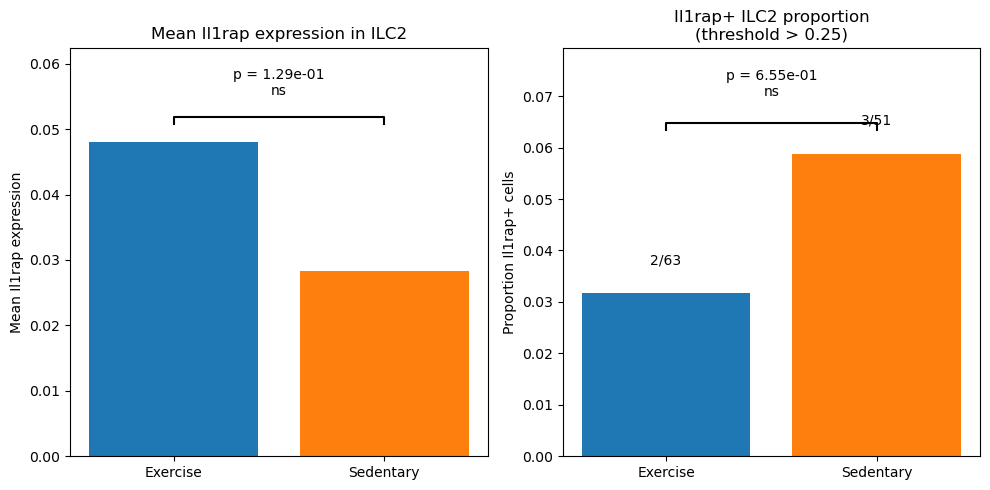

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, fisher_exact

# -----------------------------
# SETTINGS
# -----------------------------
adata = adata_immune.copy()   # use your immune AnnData
gene = "Il1rap"               # IL-33 receptor (ST2)
ilc2_label = "ILC2"           # change if your celltype label is different
pos_thresh = 0.25              # threshold for calling a cell Il1rl1+

# -----------------------------
# CHECK GENE EXISTS
# -----------------------------
if gene not in adata.var_names:
    raise ValueError(f"{gene} not found in adata.var_names")

# -----------------------------
# EXTRACT ILC2 DATA
# -----------------------------
adata_ilc2 = adata[adata.obs["celltype"] == ilc2_label].copy()

x = adata_ilc2[:, gene].X
if hasattr(x, "toarray"):
    x = x.toarray().flatten()
else:
    x = np.array(x).flatten()

df_ilc2 = pd.DataFrame({
    gene: x,
    "condition": adata_ilc2.obs["condition"].values
})

# -----------------------------
# 1A. TEST EXPRESSION LEVEL
# -----------------------------
ex_expr = df_ilc2.loc[df_ilc2["condition"] == "exercise", gene]
sed_expr = df_ilc2.loc[df_ilc2["condition"] == "sedentary", gene]

expr_stat, expr_pval = mannwhitneyu(ex_expr, sed_expr, alternative="two-sided")

print(f"{gene} expression in ILC2")
print(f"Exercise mean:   {ex_expr.mean():.4f}")
print(f"Sedentary mean:  {sed_expr.mean():.4f}")
print(f"Mann-Whitney U p-value: {expr_pval:.4e}")

# -----------------------------
# 1B. TEST PROPORTION POSITIVE
# -----------------------------
df_ilc2[f"{gene}_pos"] = df_ilc2[gene] > pos_thresh

ex_pos = df_ilc2.loc[df_ilc2["condition"] == "exercise", f"{gene}_pos"]
sed_pos = df_ilc2.loc[df_ilc2["condition"] == "sedentary", f"{gene}_pos"]

table = np.array([
    [ex_pos.sum(), (~ex_pos).sum()],
    [sed_pos.sum(), (~sed_pos).sum()]
])

oddsratio, prop_pval = fisher_exact(table)

print(f"\n{gene}+ proportion in ILC2 (threshold > {pos_thresh})")
print(f"Exercise proportion:   {ex_pos.mean():.4f}")
print(f"Sedentary proportion:  {sed_pos.mean():.4f}")
print(f"Fisher's exact p-value: {prop_pval:.4e}")
print("Contingency table:")
print(table)

# -----------------------------
# HELPER: p-value to stars
# -----------------------------
def p_to_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# -----------------------------
# PREP DATA FOR BAR PLOTS
# -----------------------------
conditions = ["exercise", "sedentary"]
condition_labels = ["Exercise", "Sedentary"]

mean_vals = [ex_expr.mean(), sed_expr.mean()]
prop_vals = [ex_pos.mean(), sed_pos.mean()]

pos_counts = [ex_pos.sum(), sed_pos.sum()]
total_counts = [len(ex_pos), len(sed_pos)]
color_map = {
    "exercise": "#1f77b4",
    "sedentary": "#ff7f0e"
}

colors = [color_map[c] for c in conditions]
# -----------------------------
# PLOT
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ---- Panel 1: mean expression ----
axes[0].bar(condition_labels, mean_vals, color=colors)
axes[0].set_ylabel(f"Mean {gene} expression")
axes[0].set_title(f"Mean {gene} expression in ILC2")


ymax1 = max(mean_vals)
line_y1 = ymax1 * 1.08
text_y1 = ymax1 * 1.14

axes[0].plot([0, 0, 1, 1], [line_y1*0.98, line_y1, line_y1, line_y1*0.98], lw=1.5, c="black")
axes[0].text(
    0.5,
    text_y1,
    f"p = {expr_pval:.2e}\n{p_to_stars(expr_pval)}",
    ha="center",
    va="bottom",
    fontsize=10
)
axes[0].set_ylim(0, ymax1 * 1.3)

# ---- Panel 2: positive proportion ----
axes[1].bar(condition_labels, prop_vals, color=colors)
axes[1].set_ylabel(f"Proportion {gene}+ cells")
axes[1].set_title(f"{gene}+ ILC2 proportion\n(threshold > {pos_thresh})")

for i, (prop, pos, total) in enumerate(zip(prop_vals, pos_counts, total_counts)):
    axes[1].text(i, prop + 0.005, f"{pos}/{total}", ha="center", va="bottom", fontsize=10)

ymax2 = max(prop_vals)
line_y2 = ymax2 * 1.10
text_y2 = ymax2 * 1.18

axes[1].plot([0, 0, 1, 1], [line_y2*0.98, line_y2, line_y2, line_y2*0.98], lw=1.5, c="black")
axes[1].text(
    0.5,
    text_y2,
    f"p = {prop_pval:.2e}\n{p_to_stars(prop_pval)}",
    ha="center",
    va="bottom",
    fontsize=10
)
axes[1].set_ylim(0, ymax2 * 1.35)

plt.tight_layout()
plt.show()

Il15 expression in Neutrophils
Exercise mean:   0.3223
Sedentary mean:  0.3698
Mann-Whitney U p-value: 2.0216e-07

Il15+ proportion in Neutrophils (threshold > 0.25)
Exercise proportion:   0.8000
Sedentary proportion:  0.7327
Fisher's exact p-value: 2.3668e-01
Contingency table:
[[152  38]
 [ 74  27]]


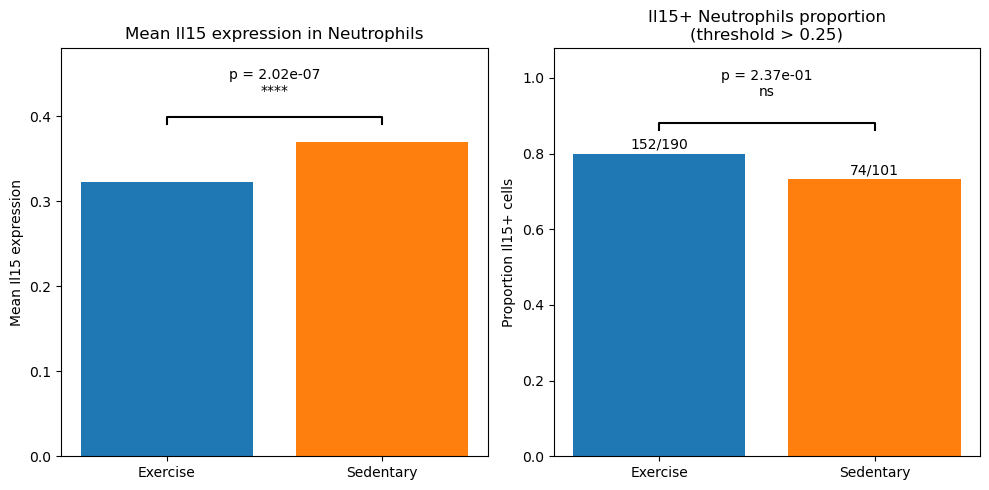

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, fisher_exact

# -----------------------------
# SETTINGS
# -----------------------------
adata = adata_immune.copy()   # use your immune AnnData
gene = "Il15"               # IL15 
neutrophil_label = "Neutrophils"           # change if your celltype label is different
pos_thresh = 0.25              # threshold for calling a cell Il15+

# -----------------------------
# CHECK GENE EXISTS
# -----------------------------
if gene not in adata.var_names:
    raise ValueError(f"{gene} not found in adata.var_names")

# -----------------------------
# EXTRACT ILC2 DATA
# -----------------------------
adata_neutrophil = adata[adata.obs["celltype"] == neutrophil_label].copy()

x = adata_neutrophil[:, gene].X
if hasattr(x, "toarray"):
    x = x.toarray().flatten()
else:
    x = np.array(x).flatten()

df_neutrophil = pd.DataFrame({
    gene: x,
    "condition": adata_neutrophil.obs["condition"].values
})

# -----------------------------
# 1A. TEST EXPRESSION LEVEL
# -----------------------------
ex_expr = df_neutrophil.loc[df_neutrophil["condition"] == "exercise", gene]
sed_expr = df_neutrophil.loc[df_neutrophil["condition"] == "sedentary", gene]

expr_stat, expr_pval = mannwhitneyu(ex_expr, sed_expr, alternative="two-sided")

print(f"{gene} expression in Neutrophils")
print(f"Exercise mean:   {ex_expr.mean():.4f}")
print(f"Sedentary mean:  {sed_expr.mean():.4f}")
print(f"Mann-Whitney U p-value: {expr_pval:.4e}")

# -----------------------------
# 1B. TEST PROPORTION POSITIVE
# -----------------------------
df_neutrophil[f"{gene}_pos"] = df_neutrophil[gene] > pos_thresh

ex_pos = df_neutrophil.loc[df_neutrophil["condition"] == "exercise", f"{gene}_pos"]
sed_pos = df_neutrophil.loc[df_neutrophil["condition"] == "sedentary", f"{gene}_pos"]

table = np.array([
    [ex_pos.sum(), (~ex_pos).sum()],
    [sed_pos.sum(), (~sed_pos).sum()]
])

oddsratio, prop_pval = fisher_exact(table)

print(f"\n{gene}+ proportion in Neutrophils (threshold > {pos_thresh})")
print(f"Exercise proportion:   {ex_pos.mean():.4f}")
print(f"Sedentary proportion:  {sed_pos.mean():.4f}")
print(f"Fisher's exact p-value: {prop_pval:.4e}")
print("Contingency table:")
print(table)

# -----------------------------
# HELPER: p-value to stars
# -----------------------------
def p_to_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# -----------------------------
# PREP DATA FOR BAR PLOTS
# -----------------------------
conditions = ["exercise", "sedentary"]
condition_labels = ["Exercise", "Sedentary"]

mean_vals = [ex_expr.mean(), sed_expr.mean()]
prop_vals = [ex_pos.mean(), sed_pos.mean()]

pos_counts = [ex_pos.sum(), sed_pos.sum()]
total_counts = [len(ex_pos), len(sed_pos)]
color_map = {
    "exercise": "#1f77b4",
    "sedentary": "#ff7f0e"
}

colors = [color_map[c] for c in conditions]
# -----------------------------
# PLOT
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ---- Panel 1: mean expression ----
axes[0].bar(condition_labels, mean_vals, color=colors)
axes[0].set_ylabel(f"Mean {gene} expression")
axes[0].set_title(f"Mean {gene} expression in Neutrophils")

ymax1 = max(mean_vals)
line_y1 = ymax1 * 1.08
text_y1 = ymax1 * 1.14

axes[0].plot([0, 0, 1, 1], [line_y1*0.98, line_y1, line_y1, line_y1*0.98], lw=1.5, c="black")
axes[0].text(
    0.5,
    text_y1,
    f"p = {expr_pval:.2e}\n{p_to_stars(expr_pval)}",
    ha="center",
    va="bottom",
    fontsize=10
)
axes[0].set_ylim(0, ymax1 * 1.3)

# ---- Panel 2: positive proportion ----
axes[1].bar(condition_labels, prop_vals, color=colors)
axes[1].set_ylabel(f"Proportion {gene}+ cells")
axes[1].set_title(f"{gene}+ Neutrophils proportion\n(threshold > {pos_thresh})")

for i, (prop, pos, total) in enumerate(zip(prop_vals, pos_counts, total_counts)):
    axes[1].text(i, prop + 0.005, f"{pos}/{total}", ha="center", va="bottom", fontsize=10)

ymax2 = max(prop_vals)
line_y2 = ymax2 * 1.10
text_y2 = ymax2 * 1.18

axes[1].plot([0, 0, 1, 1], [line_y2*0.98, line_y2, line_y2, line_y2*0.98], lw=1.5, c="black")
axes[1].text(
    0.5,
    text_y2,
    f"p = {prop_pval:.2e}\n{p_to_stars(prop_pval)}",
    ha="center",
    va="bottom",
    fontsize=10
)
axes[1].set_ylim(0, ymax2 * 1.35)

plt.tight_layout()
plt.show()

Il15ra expression in ILC2
Exercise mean:   0.0390
Sedentary mean:  0.0255
Mann-Whitney U p-value: 2.4829e-01

Il15ra+ proportion in ILC2 (threshold > 0.1)
Exercise proportion:   0.1587
Sedentary proportion:  0.0784
Fisher's exact p-value: 2.5578e-01
Contingency table:
[[10 53]
 [ 4 47]]


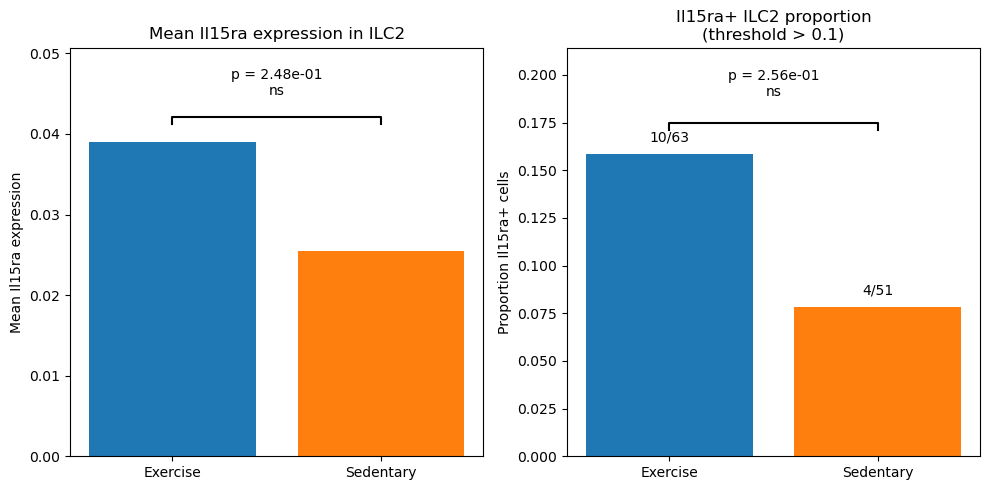

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, fisher_exact

# -----------------------------
# SETTINGS
# -----------------------------
adata = adata_immune.copy()   # use your immune AnnData
gene = "Il15ra"               # IL-33 receptor (ST2)
ilc2_label = "ILC2"           # change if your celltype label is different
pos_thresh = 0.1              # threshold for calling a cell Il1rl1+

# -----------------------------
# CHECK GENE EXISTS
# -----------------------------
if gene not in adata.var_names:
    raise ValueError(f"{gene} not found in adata.var_names")

# -----------------------------
# EXTRACT ILC2 DATA
# -----------------------------
adata_ilc2 = adata[adata.obs["celltype"] == ilc2_label].copy()

x = adata_ilc2[:, gene].X
if hasattr(x, "toarray"):
    x = x.toarray().flatten()
else:
    x = np.array(x).flatten()

df_ilc2 = pd.DataFrame({
    gene: x,
    "condition": adata_ilc2.obs["condition"].values
})

# -----------------------------
# 1A. TEST EXPRESSION LEVEL
# -----------------------------
ex_expr = df_ilc2.loc[df_ilc2["condition"] == "exercise", gene]
sed_expr = df_ilc2.loc[df_ilc2["condition"] == "sedentary", gene]

expr_stat, expr_pval = mannwhitneyu(ex_expr, sed_expr, alternative="two-sided")

print(f"{gene} expression in ILC2")
print(f"Exercise mean:   {ex_expr.mean():.4f}")
print(f"Sedentary mean:  {sed_expr.mean():.4f}")
print(f"Mann-Whitney U p-value: {expr_pval:.4e}")

# -----------------------------
# 1B. TEST PROPORTION POSITIVE
# -----------------------------
df_ilc2[f"{gene}_pos"] = df_ilc2[gene] > pos_thresh

ex_pos = df_ilc2.loc[df_ilc2["condition"] == "exercise", f"{gene}_pos"]
sed_pos = df_ilc2.loc[df_ilc2["condition"] == "sedentary", f"{gene}_pos"]

table = np.array([
    [ex_pos.sum(), (~ex_pos).sum()],
    [sed_pos.sum(), (~sed_pos).sum()]
])

oddsratio, prop_pval = fisher_exact(table)

print(f"\n{gene}+ proportion in ILC2 (threshold > {pos_thresh})")
print(f"Exercise proportion:   {ex_pos.mean():.4f}")
print(f"Sedentary proportion:  {sed_pos.mean():.4f}")
print(f"Fisher's exact p-value: {prop_pval:.4e}")
print("Contingency table:")
print(table)

# -----------------------------
# HELPER: p-value to stars
# -----------------------------
def p_to_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# -----------------------------
# PREP DATA FOR BAR PLOTS
# -----------------------------
conditions = ["exercise", "sedentary"]
condition_labels = ["Exercise", "Sedentary"]

mean_vals = [ex_expr.mean(), sed_expr.mean()]
prop_vals = [ex_pos.mean(), sed_pos.mean()]

pos_counts = [ex_pos.sum(), sed_pos.sum()]
total_counts = [len(ex_pos), len(sed_pos)]
color_map = {
    "exercise": "#1f77b4",
    "sedentary": "#ff7f0e"
}

colors = [color_map[c] for c in conditions]
# -----------------------------
# PLOT
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ---- Panel 1: mean expression ----
axes[0].bar(condition_labels, mean_vals, color=colors)
axes[0].set_ylabel(f"Mean {gene} expression")
axes[0].set_title(f"Mean {gene} expression in ILC2")

ymax1 = max(mean_vals)
line_y1 = ymax1 * 1.08
text_y1 = ymax1 * 1.14

axes[0].plot([0, 0, 1, 1], [line_y1*0.98, line_y1, line_y1, line_y1*0.98], lw=1.5, c="black")
axes[0].text(
    0.5,
    text_y1,
    f"p = {expr_pval:.2e}\n{p_to_stars(expr_pval)}",
    ha="center",
    va="bottom",
    fontsize=10
)
axes[0].set_ylim(0, ymax1 * 1.3)

# ---- Panel 2: positive proportion ----
axes[1].bar(condition_labels, prop_vals, color=colors)
axes[1].set_ylabel(f"Proportion {gene}+ cells")
axes[1].set_title(f"{gene}+ ILC2 proportion\n(threshold > {pos_thresh})")

for i, (prop, pos, total) in enumerate(zip(prop_vals, pos_counts, total_counts)):
    axes[1].text(i, prop + 0.005, f"{pos}/{total}", ha="center", va="bottom", fontsize=10)

ymax2 = max(prop_vals)
line_y2 = ymax2 * 1.10
text_y2 = ymax2 * 1.18

axes[1].plot([0, 0, 1, 1], [line_y2*0.98, line_y2, line_y2, line_y2*0.98], lw=1.5, c="black")
axes[1].text(
    0.5,
    text_y2,
    f"p = {prop_pval:.2e}\n{p_to_stars(prop_pval)}",
    ha="center",
    va="bottom",
    fontsize=10
)
axes[1].set_ylim(0, ymax2 * 1.35)

plt.tight_layout()
plt.show()

Il2rb expression in Neutrophils
Exercise mean:   0.2988
Sedentary mean:  0.3303
Mann-Whitney U p-value: 1.0588e-09

Il2rb+ proportion in Neutrophils (threshold > 0.25)
Exercise proportion:   0.8978
Sedentary proportion:  0.9126
Fisher's exact p-value: 7.0593e-01
Contingency table:
[[123  14]
 [188  18]]


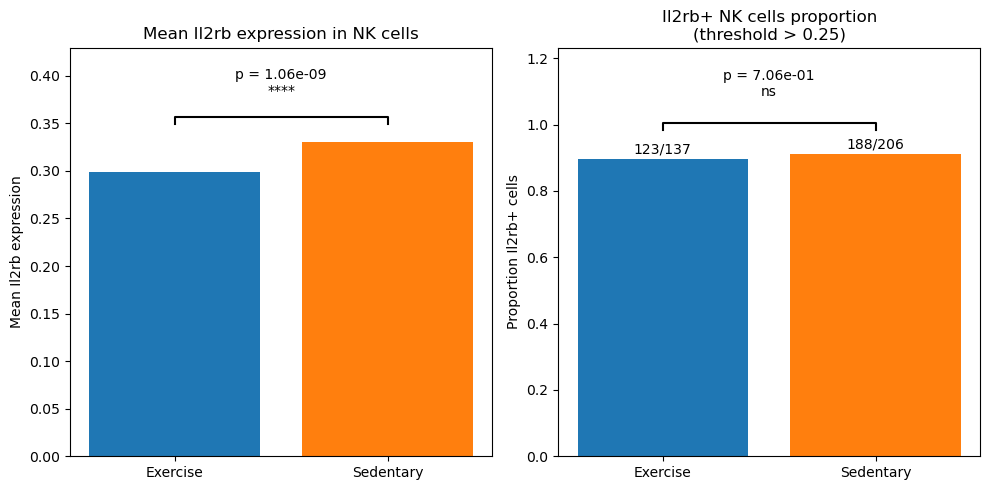

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, fisher_exact

# -----------------------------
# SETTINGS
# -----------------------------
adata = adata_immune.copy()   # use your immune AnnData
gene = "Il2rb"               # IL15 
neutrophil_label = "NK_cell"           # change if your celltype label is different
pos_thresh = 0.25              # threshold for calling a cell Il15+

# -----------------------------
# CHECK GENE EXISTS
# -----------------------------
if gene not in adata.var_names:
    raise ValueError(f"{gene} not found in adata.var_names")

# -----------------------------
# EXTRACT ILC2 DATA
# -----------------------------
adata_neutrophil = adata[adata.obs["celltype"] == neutrophil_label].copy()

x = adata_neutrophil[:, gene].X
if hasattr(x, "toarray"):
    x = x.toarray().flatten()
else:
    x = np.array(x).flatten()

df_neutrophil = pd.DataFrame({
    gene: x,
    "condition": adata_neutrophil.obs["condition"].values
})

# -----------------------------
# 1A. TEST EXPRESSION LEVEL
# -----------------------------
ex_expr = df_neutrophil.loc[df_neutrophil["condition"] == "exercise", gene]
sed_expr = df_neutrophil.loc[df_neutrophil["condition"] == "sedentary", gene]

expr_stat, expr_pval = mannwhitneyu(ex_expr, sed_expr, alternative="two-sided")

print(f"{gene} expression in Neutrophils")
print(f"Exercise mean:   {ex_expr.mean():.4f}")
print(f"Sedentary mean:  {sed_expr.mean():.4f}")
print(f"Mann-Whitney U p-value: {expr_pval:.4e}")

# -----------------------------
# 1B. TEST PROPORTION POSITIVE
# -----------------------------
df_neutrophil[f"{gene}_pos"] = df_neutrophil[gene] > pos_thresh

ex_pos = df_neutrophil.loc[df_neutrophil["condition"] == "exercise", f"{gene}_pos"]
sed_pos = df_neutrophil.loc[df_neutrophil["condition"] == "sedentary", f"{gene}_pos"]

table = np.array([
    [ex_pos.sum(), (~ex_pos).sum()],
    [sed_pos.sum(), (~sed_pos).sum()]
])

oddsratio, prop_pval = fisher_exact(table)

print(f"\n{gene}+ proportion in Neutrophils (threshold > {pos_thresh})")
print(f"Exercise proportion:   {ex_pos.mean():.4f}")
print(f"Sedentary proportion:  {sed_pos.mean():.4f}")
print(f"Fisher's exact p-value: {prop_pval:.4e}")
print("Contingency table:")
print(table)

# -----------------------------
# HELPER: p-value to stars
# -----------------------------
def p_to_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# -----------------------------
# PREP DATA FOR BAR PLOTS
# -----------------------------
conditions = ["exercise", "sedentary"]
condition_labels = ["Exercise", "Sedentary"]

mean_vals = [ex_expr.mean(), sed_expr.mean()]
prop_vals = [ex_pos.mean(), sed_pos.mean()]

pos_counts = [ex_pos.sum(), sed_pos.sum()]
total_counts = [len(ex_pos), len(sed_pos)]
color_map = {
    "exercise": "#1f77b4",
    "sedentary": "#ff7f0e"
}

colors = [color_map[c] for c in conditions]
# -----------------------------
# PLOT
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ---- Panel 1: mean expression ----
axes[0].bar(condition_labels, mean_vals, color=colors)
axes[0].set_ylabel(f"Mean {gene} expression")
axes[0].set_title(f"Mean {gene} expression in NK cells")

ymax1 = max(mean_vals)
line_y1 = ymax1 * 1.08
text_y1 = ymax1 * 1.14

axes[0].plot([0, 0, 1, 1], [line_y1*0.98, line_y1, line_y1, line_y1*0.98], lw=1.5, c="black")
axes[0].text(
    0.5,
    text_y1,
    f"p = {expr_pval:.2e}\n{p_to_stars(expr_pval)}",
    ha="center",
    va="bottom",
    fontsize=10
)
axes[0].set_ylim(0, ymax1 * 1.3)

# ---- Panel 2: positive proportion ----
axes[1].bar(condition_labels, prop_vals, color=colors)
axes[1].set_ylabel(f"Proportion {gene}+ cells")
axes[1].set_title(f"{gene}+ NK cells proportion\n(threshold > {pos_thresh})")

for i, (prop, pos, total) in enumerate(zip(prop_vals, pos_counts, total_counts)):
    axes[1].text(i, prop + 0.005, f"{pos}/{total}", ha="center", va="bottom", fontsize=10)

ymax2 = max(prop_vals)
line_y2 = ymax2 * 1.10
text_y2 = ymax2 * 1.18

axes[1].plot([0, 0, 1, 1], [line_y2*0.98, line_y2, line_y2, line_y2*0.98], lw=1.5, c="black")
axes[1].text(
    0.5,
    text_y2,
    f"p = {prop_pval:.2e}\n{p_to_stars(prop_pval)}",
    ha="center",
    va="bottom",
    fontsize=10
)
axes[1].set_ylim(0, ymax2 * 1.35)

plt.tight_layout()
plt.show()

Il2rb expression in ILC2
Exercise mean:   0.1538
Sedentary mean:  0.1690
Mann-Whitney U p-value: 2.2897e-01

Il2rb+ proportion in ILC2 (threshold > 0.25)
Exercise proportion:   0.3333
Sedentary proportion:  0.4902
Fisher's exact p-value: 1.2432e-01
Contingency table:
[[21 42]
 [25 26]]


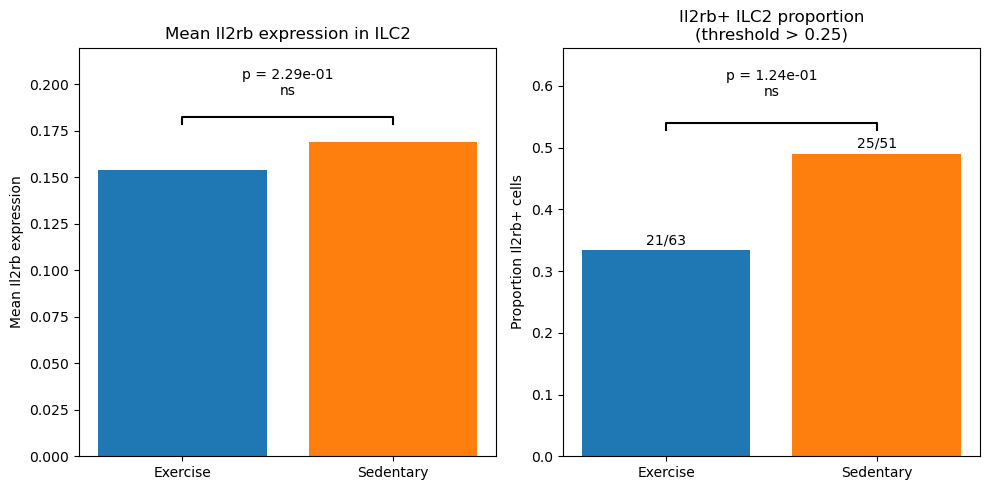

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, fisher_exact

# -----------------------------
# SETTINGS
# -----------------------------
adata = adata_immune.copy()   # use your immune AnnData
gene = "Il2rb"               # IL-33 receptor (ST2)
ilc2_label = "ILC2"           # change if your celltype label is different
pos_thresh = 0.1              # threshold for calling a cell Il1rl1+

# -----------------------------
# CHECK GENE EXISTS
# -----------------------------
if gene not in adata.var_names:
    raise ValueError(f"{gene} not found in adata.var_names")

# -----------------------------
# EXTRACT ILC2 DATA
# -----------------------------
adata_ilc2 = adata[adata.obs["celltype"] == ilc2_label].copy()

x = adata_ilc2[:, gene].X
if hasattr(x, "toarray"):
    x = x.toarray().flatten()
else:
    x = np.array(x).flatten()

df_ilc2 = pd.DataFrame({
    gene: x,
    "condition": adata_ilc2.obs["condition"].values
})

# -----------------------------
# 1A. TEST EXPRESSION LEVEL
# -----------------------------
ex_expr = df_ilc2.loc[df_ilc2["condition"] == "exercise", gene]
sed_expr = df_ilc2.loc[df_ilc2["condition"] == "sedentary", gene]

expr_stat, expr_pval = mannwhitneyu(ex_expr, sed_expr, alternative="two-sided")

print(f"{gene} expression in ILC2")
print(f"Exercise mean:   {ex_expr.mean():.4f}")
print(f"Sedentary mean:  {sed_expr.mean():.4f}")
print(f"Mann-Whitney U p-value: {expr_pval:.4e}")

# -----------------------------
# 1B. TEST PROPORTION POSITIVE
# -----------------------------
df_ilc2[f"{gene}_pos"] = df_ilc2[gene] > pos_thresh

ex_pos = df_ilc2.loc[df_ilc2["condition"] == "exercise", f"{gene}_pos"]
sed_pos = df_ilc2.loc[df_ilc2["condition"] == "sedentary", f"{gene}_pos"]

table = np.array([
    [ex_pos.sum(), (~ex_pos).sum()],
    [sed_pos.sum(), (~sed_pos).sum()]
])

oddsratio, prop_pval = fisher_exact(table)

print(f"\n{gene}+ proportion in ILC2 (threshold > {pos_thresh})")
print(f"Exercise proportion:   {ex_pos.mean():.4f}")
print(f"Sedentary proportion:  {sed_pos.mean():.4f}")
print(f"Fisher's exact p-value: {prop_pval:.4e}")
print("Contingency table:")
print(table)

# -----------------------------
# HELPER: p-value to stars
# -----------------------------
def p_to_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# -----------------------------
# PREP DATA FOR BAR PLOTS
# -----------------------------
conditions = ["exercise", "sedentary"]
condition_labels = ["Exercise", "Sedentary"]

mean_vals = [ex_expr.mean(), sed_expr.mean()]
prop_vals = [ex_pos.mean(), sed_pos.mean()]

pos_counts = [ex_pos.sum(), sed_pos.sum()]
total_counts = [len(ex_pos), len(sed_pos)]
color_map = {
    "exercise": "#1f77b4",
    "sedentary": "#ff7f0e"
}

colors = [color_map[c] for c in conditions]
# -----------------------------
# PLOT
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ---- Panel 1: mean expression ----
axes[0].bar(condition_labels, mean_vals, color=colors)
axes[0].set_ylabel(f"Mean {gene} expression")
axes[0].set_title(f"Mean {gene} expression in ILC2")

ymax1 = max(mean_vals)
line_y1 = ymax1 * 1.08
text_y1 = ymax1 * 1.14

axes[0].plot([0, 0, 1, 1], [line_y1*0.98, line_y1, line_y1, line_y1*0.98], lw=1.5, c="black")
axes[0].text(
    0.5,
    text_y1,
    f"p = {expr_pval:.2e}\n{p_to_stars(expr_pval)}",
    ha="center",
    va="bottom",
    fontsize=10
)
axes[0].set_ylim(0, ymax1 * 1.3)

# ---- Panel 2: positive proportion ----
axes[1].bar(condition_labels, prop_vals, color=colors)
axes[1].set_ylabel(f"Proportion {gene}+ cells")
axes[1].set_title(f"{gene}+ ILC2 proportion\n(threshold > {pos_thresh})")

for i, (prop, pos, total) in enumerate(zip(prop_vals, pos_counts, total_counts)):
    axes[1].text(i, prop + 0.005, f"{pos}/{total}", ha="center", va="bottom", fontsize=10)

ymax2 = max(prop_vals)
line_y2 = ymax2 * 1.10
text_y2 = ymax2 * 1.18

axes[1].plot([0, 0, 1, 1], [line_y2*0.98, line_y2, line_y2, line_y2*0.98], lw=1.5, c="black")
axes[1].text(
    0.5,
    text_y2,
    f"p = {prop_pval:.2e}\n{p_to_stars(prop_pval)}",
    ha="center",
    va="bottom",
    fontsize=10
)
axes[1].set_ylim(0, ymax2 * 1.35)

plt.tight_layout()
plt.show()

Il2rg expression in ILC2
Exercise mean:   0.2439
Sedentary mean:  0.2742
Mann-Whitney U p-value: 4.8709e-04

Il2rg+ proportion in ILC2 (threshold > 0.1)
Exercise proportion:   0.8889
Sedentary proportion:  0.8039
Fisher's exact p-value: 2.9057e-01
Contingency table:
[[56  7]
 [41 10]]


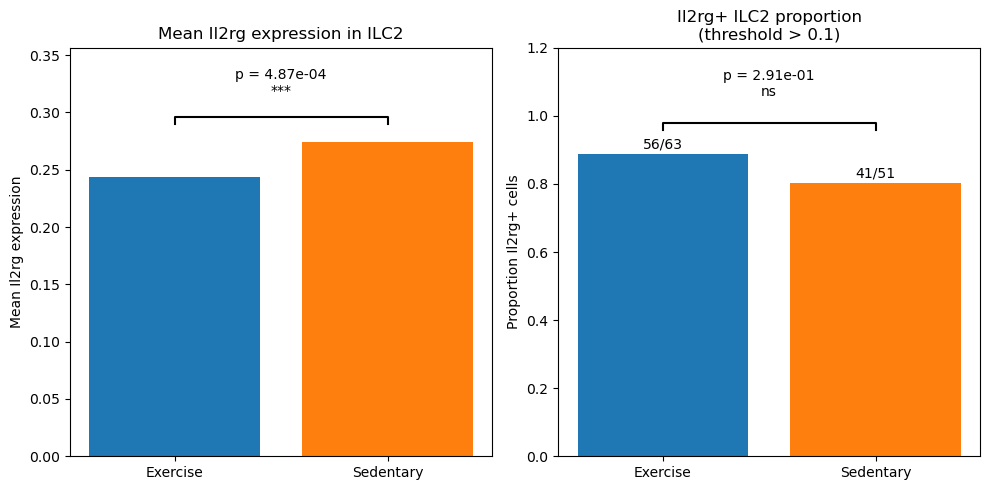

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, fisher_exact

# -----------------------------
# SETTINGS
# -----------------------------
adata = adata_immune.copy()   # use your immune AnnData
gene = "Il2rg"               # IL-33 receptor (ST2)
ilc2_label = "ILC2"           # change if your celltype label is different
pos_thresh = 0.1              # threshold for calling a cell Il1rl1+

# -----------------------------
# CHECK GENE EXISTS
# -----------------------------
if gene not in adata.var_names:
    raise ValueError(f"{gene} not found in adata.var_names")

# -----------------------------
# EXTRACT ILC2 DATA
# -----------------------------
adata_ilc2 = adata[adata.obs["celltype"] == ilc2_label].copy()

x = adata_ilc2[:, gene].X
if hasattr(x, "toarray"):
    x = x.toarray().flatten()
else:
    x = np.array(x).flatten()

df_ilc2 = pd.DataFrame({
    gene: x,
    "condition": adata_ilc2.obs["condition"].values
})

# -----------------------------
# 1A. TEST EXPRESSION LEVEL
# -----------------------------
ex_expr = df_ilc2.loc[df_ilc2["condition"] == "exercise", gene]
sed_expr = df_ilc2.loc[df_ilc2["condition"] == "sedentary", gene]

expr_stat, expr_pval = mannwhitneyu(ex_expr, sed_expr, alternative="two-sided")

print(f"{gene} expression in ILC2")
print(f"Exercise mean:   {ex_expr.mean():.4f}")
print(f"Sedentary mean:  {sed_expr.mean():.4f}")
print(f"Mann-Whitney U p-value: {expr_pval:.4e}")

# -----------------------------
# 1B. TEST PROPORTION POSITIVE
# -----------------------------
df_ilc2[f"{gene}_pos"] = df_ilc2[gene] > pos_thresh

ex_pos = df_ilc2.loc[df_ilc2["condition"] == "exercise", f"{gene}_pos"]
sed_pos = df_ilc2.loc[df_ilc2["condition"] == "sedentary", f"{gene}_pos"]

table = np.array([
    [ex_pos.sum(), (~ex_pos).sum()],
    [sed_pos.sum(), (~sed_pos).sum()]
])

oddsratio, prop_pval = fisher_exact(table)

print(f"\n{gene}+ proportion in ILC2 (threshold > {pos_thresh})")
print(f"Exercise proportion:   {ex_pos.mean():.4f}")
print(f"Sedentary proportion:  {sed_pos.mean():.4f}")
print(f"Fisher's exact p-value: {prop_pval:.4e}")
print("Contingency table:")
print(table)

# -----------------------------
# HELPER: p-value to stars
# -----------------------------
def p_to_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# -----------------------------
# PREP DATA FOR BAR PLOTS
# -----------------------------
conditions = ["exercise", "sedentary"]
condition_labels = ["Exercise", "Sedentary"]

mean_vals = [ex_expr.mean(), sed_expr.mean()]
prop_vals = [ex_pos.mean(), sed_pos.mean()]

pos_counts = [ex_pos.sum(), sed_pos.sum()]
total_counts = [len(ex_pos), len(sed_pos)]
color_map = {
    "exercise": "#1f77b4",
    "sedentary": "#ff7f0e"
}

colors = [color_map[c] for c in conditions]
# -----------------------------
# PLOT
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ---- Panel 1: mean expression ----
axes[0].bar(condition_labels, mean_vals, color=colors)
axes[0].set_ylabel(f"Mean {gene} expression")
axes[0].set_title(f"Mean {gene} expression in ILC2")

ymax1 = max(mean_vals)
line_y1 = ymax1 * 1.08
text_y1 = ymax1 * 1.14

axes[0].plot([0, 0, 1, 1], [line_y1*0.98, line_y1, line_y1, line_y1*0.98], lw=1.5, c="black")
axes[0].text(
    0.5,
    text_y1,
    f"p = {expr_pval:.2e}\n{p_to_stars(expr_pval)}",
    ha="center",
    va="bottom",
    fontsize=10
)
axes[0].set_ylim(0, ymax1 * 1.3)

# ---- Panel 2: positive proportion ----
axes[1].bar(condition_labels, prop_vals, color=colors)
axes[1].set_ylabel(f"Proportion {gene}+ cells")
axes[1].set_title(f"{gene}+ ILC2 proportion\n(threshold > {pos_thresh})")

for i, (prop, pos, total) in enumerate(zip(prop_vals, pos_counts, total_counts)):
    axes[1].text(i, prop + 0.005, f"{pos}/{total}", ha="center", va="bottom", fontsize=10)

ymax2 = max(prop_vals)
line_y2 = ymax2 * 1.10
text_y2 = ymax2 * 1.18

axes[1].plot([0, 0, 1, 1], [line_y2*0.98, line_y2, line_y2, line_y2*0.98], lw=1.5, c="black")
axes[1].text(
    0.5,
    text_y2,
    f"p = {prop_pval:.2e}\n{p_to_stars(prop_pval)}",
    ha="center",
    va="bottom",
    fontsize=10
)
axes[1].set_ylim(0, ymax2 * 1.35)

plt.tight_layout()
plt.show()

Cxcl14 expression in ILC2
Exercise mean:   2.5268
Sedentary mean:  2.8289
Mann-Whitney U p-value: 4.4147e-22

Cxcl14+ proportion in ILC2 (threshold > 0.5)
Exercise proportion:   0.8571
Sedentary proportion:  0.9233
Fisher's exact p-value: 3.3415e-28
Contingency table:
[[4293  716]
 [5258  437]]


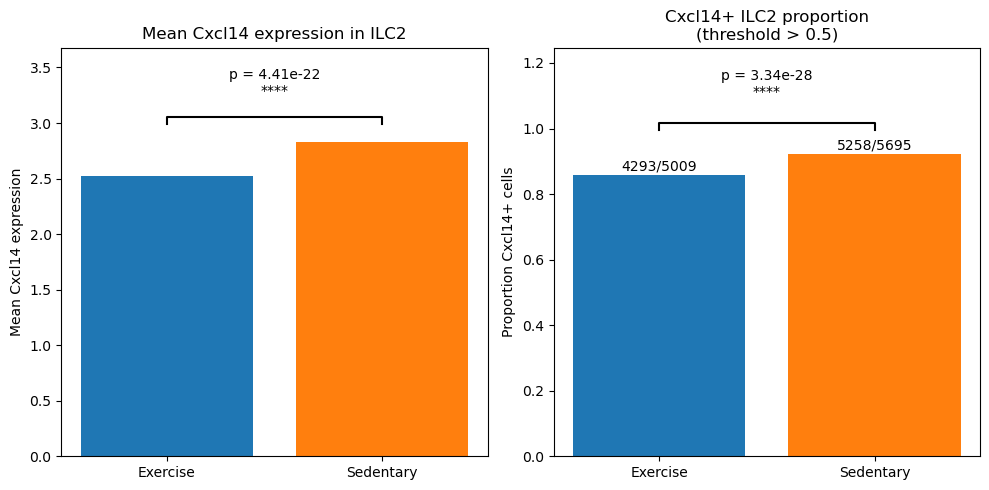

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, fisher_exact

# -----------------------------
# SETTINGS
# -----------------------------
adata = adata_fap.copy()   # use your immune AnnData
gene = "Cxcl14"               # IL-33 receptor (ST2)
ilc2_label = "Cxcl14+"           # change if your celltype label is different
pos_thresh = 0.5              # threshold for calling a cell Il1rl1+

# -----------------------------
# CHECK GENE EXISTS
# -----------------------------
if gene not in adata.var_names:
    raise ValueError(f"{gene} not found in adata.var_names")

# -----------------------------
# EXTRACT ILC2 DATA
# -----------------------------
adata_ilc2 = adata[adata.obs["celltype"] == ilc2_label].copy()

x = adata_ilc2[:, gene].X
if hasattr(x, "toarray"):
    x = x.toarray().flatten()
else:
    x = np.array(x).flatten()

df_ilc2 = pd.DataFrame({
    gene: x,
    "condition": adata_ilc2.obs["condition"].values
})

# -----------------------------
# 1A. TEST EXPRESSION LEVEL
# -----------------------------
ex_expr = df_ilc2.loc[df_ilc2["condition"] == "exercise", gene]
sed_expr = df_ilc2.loc[df_ilc2["condition"] == "sedentary", gene]

expr_stat, expr_pval = mannwhitneyu(ex_expr, sed_expr, alternative="two-sided")

print(f"{gene} expression in ILC2")
print(f"Exercise mean:   {ex_expr.mean():.4f}")
print(f"Sedentary mean:  {sed_expr.mean():.4f}")
print(f"Mann-Whitney U p-value: {expr_pval:.4e}")

# -----------------------------
# 1B. TEST PROPORTION POSITIVE
# -----------------------------
df_ilc2[f"{gene}_pos"] = df_ilc2[gene] > pos_thresh

ex_pos = df_ilc2.loc[df_ilc2["condition"] == "exercise", f"{gene}_pos"]
sed_pos = df_ilc2.loc[df_ilc2["condition"] == "sedentary", f"{gene}_pos"]

table = np.array([
    [ex_pos.sum(), (~ex_pos).sum()],
    [sed_pos.sum(), (~sed_pos).sum()]
])

oddsratio, prop_pval = fisher_exact(table)

print(f"\n{gene}+ proportion in ILC2 (threshold > {pos_thresh})")
print(f"Exercise proportion:   {ex_pos.mean():.4f}")
print(f"Sedentary proportion:  {sed_pos.mean():.4f}")
print(f"Fisher's exact p-value: {prop_pval:.4e}")
print("Contingency table:")
print(table)

# -----------------------------
# HELPER: p-value to stars
# -----------------------------
def p_to_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# -----------------------------
# PREP DATA FOR BAR PLOTS
# -----------------------------
conditions = ["exercise", "sedentary"]
condition_labels = ["Exercise", "Sedentary"]

mean_vals = [ex_expr.mean(), sed_expr.mean()]
prop_vals = [ex_pos.mean(), sed_pos.mean()]

pos_counts = [ex_pos.sum(), sed_pos.sum()]
total_counts = [len(ex_pos), len(sed_pos)]
color_map = {
    "exercise": "#1f77b4",
    "sedentary": "#ff7f0e"
}

colors = [color_map[c] for c in conditions]
# -----------------------------
# PLOT
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ---- Panel 1: mean expression ----
axes[0].bar(condition_labels, mean_vals, color=colors)
axes[0].set_ylabel(f"Mean {gene} expression")
axes[0].set_title(f"Mean {gene} expression in ILC2")

ymax1 = max(mean_vals)
line_y1 = ymax1 * 1.08
text_y1 = ymax1 * 1.14

axes[0].plot([0, 0, 1, 1], [line_y1*0.98, line_y1, line_y1, line_y1*0.98], lw=1.5, c="black")
axes[0].text(
    0.5,
    text_y1,
    f"p = {expr_pval:.2e}\n{p_to_stars(expr_pval)}",
    ha="center",
    va="bottom",
    fontsize=10
)
axes[0].set_ylim(0, ymax1 * 1.3)

# ---- Panel 2: positive proportion ----
axes[1].bar(condition_labels, prop_vals, color=colors)
axes[1].set_ylabel(f"Proportion {gene}+ cells")
axes[1].set_title(f"{gene}+ ILC2 proportion\n(threshold > {pos_thresh})")

for i, (prop, pos, total) in enumerate(zip(prop_vals, pos_counts, total_counts)):
    axes[1].text(i, prop + 0.005, f"{pos}/{total}", ha="center", va="bottom", fontsize=10)

ymax2 = max(prop_vals)
line_y2 = ymax2 * 1.10
text_y2 = ymax2 * 1.18

axes[1].plot([0, 0, 1, 1], [line_y2*0.98, line_y2, line_y2, line_y2*0.98], lw=1.5, c="black")
axes[1].text(
    0.5,
    text_y2,
    f"p = {prop_pval:.2e}\n{p_to_stars(prop_pval)}",
    ha="center",
    va="bottom",
    fontsize=10
)
axes[1].set_ylim(0, ymax2 * 1.35)

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# -----------------------------
# EXTRACT WHOLE IMMUNE DATA
# -----------------------------
x = adata[:, gene].X
if hasattr(x, "toarray"):
    x = x.toarray().flatten()
else:
    x = np.array(x).flatten()

df = pd.DataFrame({
    gene: x,
    "celltype": adata.obs["celltype"].values,
    "condition": adata.obs["condition"].values
})

df[f"{gene}_pos"] = df[gene] > pos_thresh

celltypes = df["celltype"].unique().tolist()
results = []

for ct in celltypes:
    sub = df[df["celltype"] == ct].copy()

    ex = sub[sub["condition"] == "exercise"][f"{gene}_pos"]
    sed = sub[sub["condition"] == "sedentary"][f"{gene}_pos"]

    # skip if one group is empty
    if len(ex) == 0 or len(sed) == 0:
        continue

    table = np.array([
        [ex.sum(), (~ex).sum()],
        [sed.sum(), (~sed).sum()]
    ])

    oddsratio, pval = fisher_exact(table)

    results.append({
        "celltype": ct,
        "exercise_prop": ex.mean(),
        "sedentary_prop": sed.mean(),
        "delta": ex.mean() - sed.mean(),
        "oddsratio": oddsratio,
        "pval": pval,
        "exercise_n": len(ex),
        "sedentary_n": len(sed),
        "exercise_pos_n": int(ex.sum()),
        "sedentary_pos_n": int(sed.sum())
    })

results_df = pd.DataFrame(results)

# multiple testing correction
results_df["padj"] = multipletests(results_df["pval"], method="fdr_bh")[1]

# sort by delta
results_df = results_df.sort_values("delta", ascending=False)

print(results_df)

      celltype  exercise_prop  sedentary_prop     delta  oddsratio      pval  \
0       B_Cell       0.000000        0.000000  0.000000        NaN  1.000000   
4      NK_cell       0.000000        0.000000  0.000000        NaN  1.000000   
3  Macrophages       0.000000        0.000000  0.000000        NaN  1.000000   
6    CD4_Tcell       0.000000        0.000000  0.000000        NaN  1.000000   
5    CD8_Tcell       0.000000        0.000000  0.000000        NaN  1.000000   
7  Neutrophils       0.000000        0.000000  0.000000        NaN  1.000000   
8       T_cell       0.000000        0.000000  0.000000        NaN  1.000000   
1         ILC2       0.015873        0.098039 -0.082166   0.148387  0.087721   
2    Mast_cell       0.000000        0.125000 -0.125000   0.000000  1.000000   

   exercise_n  sedentary_n  exercise_pos_n  sedentary_pos_n     padj  
0         138          136               0                0  1.00000  
4         137          206               0               

In [46]:
import scanpy as sc

sc.pp.normalize_total(adata_immune)
sc.pp.log1p(adata_immune)

In [49]:
adata_immune = adata_immune.copy()

import liana as li

li.mt.cellphonedb(
    adata_immune,
    groupby="celltype",
    resource_name="mouseconsensus",
    expr_prop=0.1,
    use_raw=False,
    n_perms=1000
)

/home/rc2020/miniconda3/envs/liana_only/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/rc2020/miniconda3/envs/liana_only/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


In [50]:
res = adata_immune.uns["liana_res"]
res.head()

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
9856,Mmp9,Mmp9,0.379035,0.886598,Cd44,Cd44,0.446281,0.986254,Neutrophils,Neutrophils,0.412658,0.0
9874,Pkm,Pkm,0.342199,0.821306,Cd44,Cd44,0.446281,0.986254,Neutrophils,Neutrophils,0.394240,0.0
9819,Il1b,Il1b,0.452881,0.979381,Il1rap,Il1r2_Il1rap,0.329616,0.776632,Neutrophils,Neutrophils,0.391249,0.0
9853,Gnai2,Gnai2,0.401638,0.931271,C5ar1,C5ar1,0.369820,0.865979,Neutrophils,Neutrophils,0.385729,0.0
9826,S100a9,S100a9,0.475960,0.989691,Itgb2,Itgb2,0.290827,0.721649,Neutrophils,Neutrophils,0.383393,0.0


In [51]:
res[
    (res["ligand"] == "Il15") &
    (res["target"] == "ILC2")
].sort_values("lr_means", ascending=False)

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
4102,Il15,Il15,0.338791,0.783505,Il2ra,Il2ra,0.270683,0.859649,Neutrophils,ILC2,0.304737,0.000
3865,Il15,Il15,0.198546,0.533333,Il2ra,Il2ra,0.270683,0.859649,Mast_cell,ILC2,0.234614,0.000
4099,Il15,Il15,0.338791,0.783505,Il15ra,Il15ra_Il2rb_Il2rg,0.032937,0.122807,Neutrophils,ILC2,0.185864,0.000
3693,Il15,Il15,0.041803,0.204255,Il2ra,Il2ra,0.270683,0.859649,Macrophages,ILC2,0.156243,0.000
3862,Il15,Il15,0.198546,0.533333,Il15ra,Il15ra_Il2rb_Il2rg,0.032937,0.122807,Mast_cell,ILC2,0.115742,0.000
3690,Il15,Il15,0.041803,0.204255,Il15ra,Il15ra_Il2rb_Il2rg,0.032937,0.122807,Macrophages,ILC2,0.037370,0.293


In [52]:
res[
    (res["ligand"] == "Il15") &
    (res["target"] == "ILC2")
].sort_values("lr_means", ascending=False)

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
4102,Il15,Il15,0.338791,0.783505,Il2ra,Il2ra,0.270683,0.859649,Neutrophils,ILC2,0.304737,0.000
3865,Il15,Il15,0.198546,0.533333,Il2ra,Il2ra,0.270683,0.859649,Mast_cell,ILC2,0.234614,0.000
4099,Il15,Il15,0.338791,0.783505,Il15ra,Il15ra_Il2rb_Il2rg,0.032937,0.122807,Neutrophils,ILC2,0.185864,0.000
3693,Il15,Il15,0.041803,0.204255,Il2ra,Il2ra,0.270683,0.859649,Macrophages,ILC2,0.156243,0.000
3862,Il15,Il15,0.198546,0.533333,Il15ra,Il15ra_Il2rb_Il2rg,0.032937,0.122807,Mast_cell,ILC2,0.115742,0.000
3690,Il15,Il15,0.041803,0.204255,Il15ra,Il15ra_Il2rb_Il2rg,0.032937,0.122807,Macrophages,ILC2,0.037370,0.293


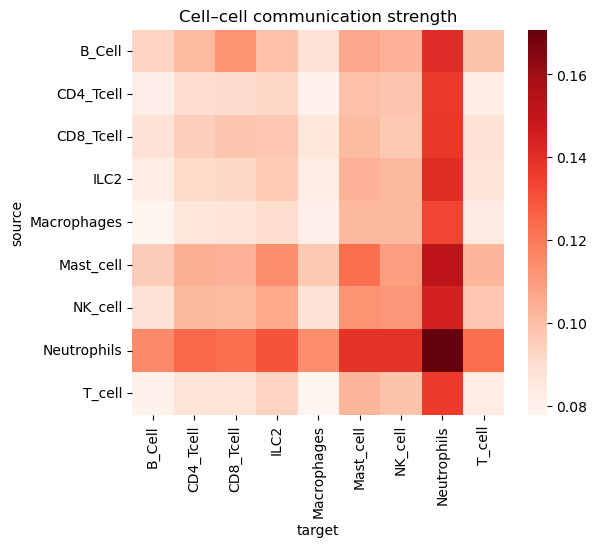

In [51]:
pivot = res.pivot_table(
    index="source",
    columns="target",
    values="lr_means",
    aggfunc="mean"
)

plt.figure(figsize=(6,5))
sns.heatmap(pivot, cmap="Reds")
plt.title("Cell–cell communication strength")
plt.show()

In [53]:
res = adata_immune.uns["liana_res"]

il15 = res[res["ligand"]=="Il15"]

il15.sort_values("lr_means", ascending=False).head(10)

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
4102,Il15,Il15,0.296642,0.783505,Il2ra,Il2ra,0.234747,0.859649,Neutrophils,ILC2,0.265694,0.000
3865,Il15,Il15,0.173107,0.533333,Il2ra,Il2ra,0.234747,0.859649,Mast_cell,ILC2,0.203927,0.000
11432,Il15,Il15,0.296642,0.783505,Il2ra,Il2ra,0.052079,0.262626,Neutrophils,T_cell,0.174361,0.000
4099,Il15,Il15,0.296642,0.783505,Il15ra,Il15ra_Il2rb_Il2rg,0.028891,0.122807,Neutrophils,ILC2,0.162767,0.000
3693,Il15,Il15,0.036553,0.204255,Il2ra,Il2ra,0.234747,0.859649,Macrophages,ILC2,0.135650,0.000
11108,Il15,Il15,0.173107,0.533333,Il2ra,Il2ra,0.052079,0.262626,Mast_cell,T_cell,0.112593,0.000
3862,Il15,Il15,0.173107,0.533333,Il15ra,Il15ra_Il2rb_Il2rg,0.028891,0.122807,Mast_cell,ILC2,0.100999,0.000
10881,Il15,Il15,0.036553,0.204255,Il2ra,Il2ra,0.052079,0.262626,Macrophages,T_cell,0.044316,0.067
3690,Il15,Il15,0.036553,0.204255,Il15ra,Il15ra_Il2rb_Il2rg,0.028891,0.122807,Macrophages,ILC2,0.032722,0.297


In [55]:
neuts = adata_lr[adata_lr.obs["celltype"] == "Neutrophils"]

(neuts.to_df()["Il15"] > 0).groupby(neuts.obs["condition"]).mean()

condition
exercise     0.810526
sedentary    0.732673
Name: Il15, dtype: float64

In [56]:
ilc2s = adata_lr[adata_lr.obs["celltype"] == "ILC2"]

(ilc2s.to_df()["Il15"] > 0).groupby(ilc2s.obs["condition"]).mean()

condition
exercise     0.047619
sedentary    0.000000
Name: Il15, dtype: float64

In [57]:
ilc2s = adata_lr[adata_lr.obs["celltype"] == "ILC2"]

(ilc2s.to_df()["Il15ra"] > 0).groupby(ilc2s.obs["condition"]).mean()

condition
exercise     0.158730
sedentary    0.078431
Name: Il15ra, dtype: float64

In [58]:
ilc2s = adata_lr[adata_lr.obs["celltype"] == "ILC2"]

(ilc2s.to_df()["Il2rg"] > 0).groupby(ilc2s.obs["condition"]).mean()

condition
exercise     0.888889
sedentary    0.803922
Name: Il2rg, dtype: float64

In [59]:
adata_ex = adata_lr[adata_lr.obs["condition"]=="exercise"].copy()
adata_sed = adata_lr[adata_lr.obs["condition"]=="sedentary"].copy()

In [60]:
li.mt.cellphonedb(
    adata_ex,
    groupby="celltype",
    resource_name="mouseconsensus",
    expr_prop=0.1,
    use_raw=False,
    n_perms=1000
)
lr_ex = adata_ex.uns["liana_res"]

/home/rc2020/miniconda3/envs/liana_only/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/rc2020/miniconda3/envs/liana_only/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


In [61]:
li.mt.cellphonedb(
    adata_sed,
    groupby="celltype",
    resource_name="mouseconsensus",
    expr_prop=0.1,
    use_raw=False,
    n_perms=1000
)
lr_sed = adata_sed.uns["liana_res"]

/home/rc2020/miniconda3/envs/liana_only/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/rc2020/miniconda3/envs/liana_only/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


In [62]:
lr_ex_il15 = lr_ex[
    (lr_ex["ligand"]=="Il15") &
    (lr_ex["source"]=="Neutrophils") &
    (lr_ex["target"]=="ILC2")
]

lr_sed_il15 = lr_sed[
    (lr_sed["ligand"]=="Il15") &
    (lr_sed["source"]=="Neutrophils") &
    (lr_sed["target"]=="ILC2")
]

In [63]:
print(lr_ex_il15[["ligand","receptor","lr_means","cellphone_pvals"]])
print(lr_sed_il15[["ligand","receptor","lr_means","cellphone_pvals"]])

    ligand receptor  lr_means  cellphone_pvals
238   Il15    Il2ra  0.280357              0.0
235   Il15   Il15ra  0.180638              0.0
    ligand receptor  lr_means  cellphone_pvals
173   Il15    Il2ra  0.340186              0.0


In [64]:
lr_ex_il15["condition"] = "exercise"
lr_sed_il15["condition"] = "sedentary"

lr_compare = pd.concat([lr_ex_il15, lr_sed_il15])

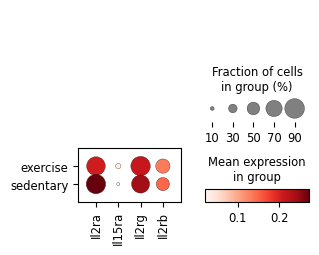

In [69]:
receptors = ["Il2ra","Il15ra","Il2rg","Il2rb"]

sc.pl.dotplot(
    adata_lr[adata_lr.obs["celltype"]=="ILC2"],
    receptors,
    groupby="condition"
)

In [70]:
adata_lr.obs.groupby(["celltype","condition"]).size()

celltype     condition
ILC2         exercise      63
             sedentary     51
Neutrophils  exercise     190
             sedentary    101
dtype: int64

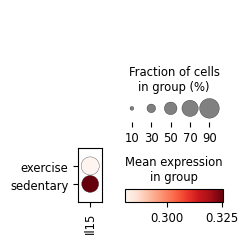

In [71]:
sc.pl.dotplot(
    adata_immune[adata_immune.obs["celltype"]=="Neutrophils"],
    ["Il15"],
    groupby="condition"
)

In [72]:
palette = {
    "exercise": "#1f77b4",
    "sedentary": "#ff7f0e"}

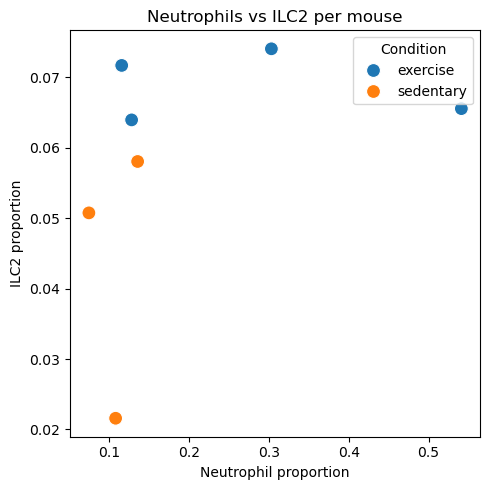

In [73]:

# color palette
palette = {
    "exercise": "#1f77b4",
    "sedentary": "#ff7f0e"
}

# rebuild counts table from scratch
counts = adata_immune.obs.groupby(["mouse_id", "celltype"]).size().unstack().fillna(0)

counts["total"] = counts.sum(axis=1)
counts["neut_prop"] = counts["Neutrophils"] / counts["total"]
counts["ilc2_prop"] = counts["ILC2"] / counts["total"]

# add condition back per mouse
mouse_condition = (
    adata_immune.obs[["mouse_id", "condition"]]
    .drop_duplicates()
)

counts = counts.reset_index().merge(mouse_condition, on="mouse_id", how="left")

# plot
plt.figure(figsize=(5,5))

sns.scatterplot(
    data=counts,
    x="neut_prop",
    y="ilc2_prop",
    hue="condition",
    palette=palette,
    s=100
)

plt.xlabel("Neutrophil proportion")
plt.ylabel("ILC2 proportion")
plt.title("Neutrophils vs ILC2 per mouse")
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

  mouse_id  condition  fap_prop  ilc2_prop
0   Mouse1  sedentary  0.124734   0.058065
1   Mouse2  sedentary  0.091134   0.021583
2   Mouse3  sedentary  0.045257   0.050761
3   Mouse4   exercise  0.033705   0.063973
4   Mouse5   exercise  0.036173   0.074074
5   Mouse6   exercise  0.031349   0.071713
6   Mouse7   exercise  0.061692   0.065574


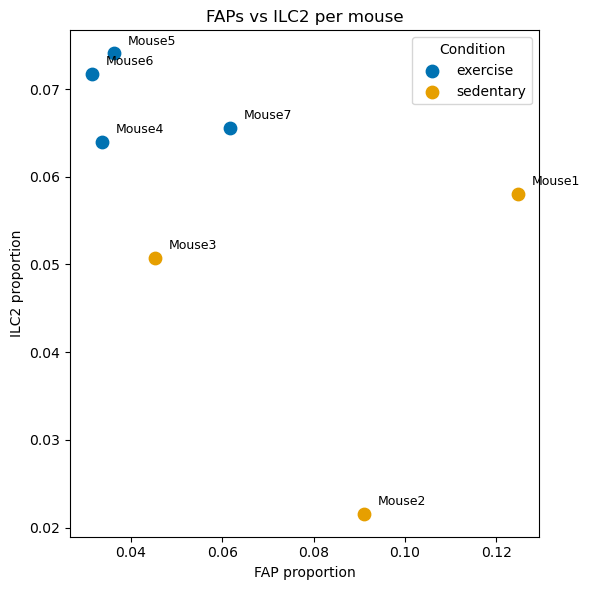

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------
# SETTINGS
# --------------------------
sample_col = "mouse_id"
condition_col = "condition"
fap_label = "FAP"      # change if needed
ilc2_label = "ILC2"

# --------------------------
# FAP proportion per mouse
# --------------------------
fap_counts = (
    adata_fap.obs
    .groupby([sample_col, condition_col, "celltype"])
    .size()
    .reset_index(name="n")
)

fap_totals = (
    adata_fap.obs
    .groupby([sample_col, condition_col])
    .size()
    .reset_index(name="total")
)

fap_props = fap_counts.merge(fap_totals, on=[sample_col, condition_col])
fap_props["prop"] = fap_props["n"] / fap_props["total"]

fap_only = fap_props[fap_props["celltype"] == fap_label][
    [sample_col, condition_col, "prop"]
].rename(columns={"prop": "fap_prop"})

# --------------------------
# ILC2 proportion per mouse
# --------------------------
immune_counts = (
    adata_immune.obs
    .groupby([sample_col, condition_col, "celltype"])
    .size()
    .reset_index(name="n")
)

immune_totals = (
    adata_immune.obs
    .groupby([sample_col, condition_col])
    .size()
    .reset_index(name="total")
)

immune_props = immune_counts.merge(immune_totals, on=[sample_col, condition_col])
immune_props["prop"] = immune_props["n"] / immune_props["total"]

ilc2_only = immune_props[immune_props["celltype"] == ilc2_label][
    [sample_col, condition_col, "prop"]
].rename(columns={"prop": "ilc2_prop"})

# --------------------------
# Merge by mouse
# --------------------------
plot_df = fap_only.merge(ilc2_only, on=[sample_col, condition_col], how="inner")

print(plot_df)

# --------------------------
# Plot
# --------------------------
colors = {
    "exercise": "#0072B2",
    "sedentary": "#E69F00"
}

plt.figure(figsize=(6, 6))

for cond in ["exercise", "sedentary"]:
    sub = plot_df[plot_df[condition_col] == cond]
    plt.scatter(
        sub["fap_prop"],
        sub["ilc2_prop"],
        s=80,
        color=colors[cond],
        label=cond
    )

    # Optional: label points by mouse
    for _, row in sub.iterrows():
        plt.text(
            row["fap_prop"] + 0.003,
            row["ilc2_prop"] + 0.001,
            row[sample_col],
            fontsize=9
        )

plt.xlabel("FAP proportion")
plt.ylabel("ILC2 proportion")
plt.title("FAPs vs ILC2 per mouse")
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

# ILC2 and FAPS

In [75]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import liana as li

# -----------------------------
# 1. Keep only shared genes
# -----------------------------
shared_genes = adata_fap.var_names.intersection(adata_immune.var_names)

adata_fap_sub = adata_fap[:, shared_genes].copy()
adata_immune_sub = adata_immune[:, shared_genes].copy()

# -----------------------------
# 2. Make sure celltype + condition columns exist
# -----------------------------
for adata_obj in [adata_fap_sub, adata_immune_sub]:
    if "celltype" not in adata_obj.obs.columns:
        raise ValueError("Need a 'celltype' column in .obs")
    if "condition" not in adata_obj.obs.columns:
        raise ValueError("Need a 'condition' column in .obs")

# Optional: add source label
adata_fap_sub.obs["compartment"] = "FAP"
adata_immune_sub.obs["compartment"] = "Immune"

# -----------------------------
# 3. Concatenate into one object
# -----------------------------
adata_combined = ad.concat(
    [adata_fap_sub, adata_immune_sub],
    join="inner",
    label="dataset",
    keys=["fap", "immune"],
    merge="same"
)

# Make sure celltype is categorical
adata_combined.obs["celltype"] = adata_combined.obs["celltype"].astype("category")
adata_combined.obs["condition"] = adata_combined.obs["condition"].astype("category")

print(adata_combined)
print(adata_combined.obs["celltype"].value_counts())

AnnData object with n_obs × n_vars = 29332 × 19733
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'low_n_genes', 'high_mt', 'high_counts', 'doublet_score', 'predicted_doublet', 'mouse_id', 'condition', 'leiden', 'celltype', 'compartment', 'dataset'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts-Mice1', 'mean_counts-Mice1', 'pct_dropout_by_counts-Mice1', 'total_counts-Mice1', 'n_cells_by_counts-Mice2', 'mean_counts-Mice2', 'pct_dropout_by_counts-Mice2', 'total_counts-Mice2', 'n_cells_by_counts-Mice3', 'mean_counts-Mice3', 'pct_dropout_by_counts-Mice3', 'total_counts-Mice3', 'n_cells_by_counts-Mice4', 'mean_counts-Mice4', 'pct_dropout_by_counts-Mice4', 'total_counts-Mice4', 'n_cells_by_counts-Mice5', 'mean_counts-Mice5', 'pct_dropout_by_counts-Mice5', 'total_counts-Mice5', 'n_cells_by_counts-Mice6', 'mean_counts-Mice6', 'pct_dropout_by_counts-Mice6', 'total_counts-Mice6', 'n_cells_by_counts-Mice7', 'mean_counts-Mice7', 'pct_dropout_by_co

In [18]:
# Exercise only
adata_ex = adata_combined[adata_combined.obs["condition"] == "exercise"].copy()

li.mt.cellphonedb(
    adata_ex,
    groupby="celltype",
    resource_name="mouseconsensus",
    expr_prop=0.1,
    verbose=True,
    use_raw=False,
    n_perms=1000
)


lr_ex = adata_ex.uns["liana_res"].copy()
print(lr_ex.head())

Using resource `mouseconsensus`.
Using `.X`!
/home/rc2020/miniconda3/envs/liana_only/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
1 features of mat are empty, they will be removed.
/home/rc2020/miniconda3/envs/liana_only/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
0.19 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 13964 samples and 1249 features


100%|██████████| 1000/1000 [00:25<00:00, 38.91it/s]


      ligand ligand_complex  ligand_means  ligand_props receptor  \
30704    Dcn            Dcn       5.94247           1.0     Egfr   
23929    Dcn            Dcn       5.94247           1.0     Egfr   
41580    Dcn            Dcn       5.94247           1.0     Egfr   
16229    Dcn            Dcn       5.94247           1.0     Egfr   
67019    Dcn            Dcn       5.94247           1.0     Egfr   

      receptor_complex  receptor_means  receptor_props source   target  \
30704             Egfr        1.949671        0.901919  Sca1-      FAP   
23929             Egfr        1.813030        0.976842  Sca1-  Cxcl14+   
41580             Egfr        1.623817        0.961666  Sca1-  IPC_Skm   
16229             Egfr        1.493779        0.910320  Sca1-   CD142+   
67019             Egfr        1.311401        0.919536  Sca1-    Prg4+   

       lr_means  cellphone_pvals  
30704  3.946071              0.0  
23929  3.877750              0.0  
41580  3.783144              0.0  
16229 

In [19]:
# Sedentary only
adata_sed = adata_combined[adata_combined.obs["condition"] == "sedentary"].copy()

li.mt.cellphonedb(
    adata_sed,
    groupby="celltype",
    resource_name="mouseconsensus",
    expr_prop=0.1,
    verbose=True,
    use_raw=False,
     n_perms=1000
)

lr_sed = adata_sed.uns["liana_res"].copy()
print(lr_sed.head())

Using resource `mouseconsensus`.
Using `.X`!
/home/rc2020/miniconda3/envs/liana_only/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
4 features of mat are empty, they will be removed.
/home/rc2020/miniconda3/envs/liana_only/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
0.19 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 15368 samples and 1248 features


100%|██████████| 1000/1000 [00:24<00:00, 41.40it/s]


      ligand ligand_complex  ligand_means  ligand_props receptor  \
24375    Dcn            Dcn      5.774894           1.0     Egfr   
19101    Dcn            Dcn      5.774894           1.0     Egfr   
33352    Dcn            Dcn      5.774894           1.0     Egfr   
12911    Dcn            Dcn      5.774894           1.0     Egfr   
20998    Dcn            Dcn      5.293795           1.0     Egfr   

      receptor_complex  receptor_means  receptor_props   source   target  \
24375             Egfr        2.110073        0.910008    Sca1-      FAP   
19101             Egfr        1.982188        0.967164    Sca1-  Cxcl14+   
33352             Egfr        1.843454        0.959475    Sca1-  IPC_Skm   
12911             Egfr        1.675622        0.905356    Sca1-   CD142+   
20998             Egfr        2.110073        0.910008  Cxcl14+      FAP   

       lr_means  cellphone_pvals  
24375  3.942483              0.0  
19101  3.878541              0.0  
33352  3.809174              

In [20]:
# Exercise
il33_ex = lr_ex[
    (lr_ex["ligand"] == "Il33") &
    (lr_ex["receptor_complex"].fillna("").str.contains("Il1rl1")) &
    (lr_ex["receptor_complex"].fillna("").str.contains("Il1rap"))
].copy()

# Sedentary
il33_sed = lr_sed[
    (lr_sed["ligand"] == "Il33") &
    (lr_sed["receptor_complex"].fillna("").str.contains("Il1rl1")) &
    (lr_sed["receptor_complex"].fillna("").str.contains("Il1rap"))
].copy()

print("Exercise IL33 receptor-complex interactions:")
print(il33_ex.sort_values("lr_means", ascending=False).head(20))

print("\nSedentary IL33 receptor-complex interactions:")
print(il33_sed.sort_values("lr_means", ascending=False).head(20))

Exercise IL33 receptor-complex interactions:
      ligand ligand_complex  ligand_means  ligand_props receptor  \
53167   Il33           Il33      1.284197      0.810526   Il1rap   
34398   Il33           Il33      1.284197      0.810526   Il1rap   
79617   Il33           Il33      1.284197      0.810526   Il1rl1   
47958   Il33           Il33      1.284197      0.810526   Il1rl1   
51227   Il33           Il33      0.793014      0.708421   Il1rap   
50012   Il33           Il33      0.782985      0.673188   Il1rap   
33047   Il33           Il33      0.793014      0.708421   Il1rap   
32237   Il33           Il33      0.782985      0.673188   Il1rap   
77590   Il33           Il33      0.793014      0.708421   Il1rl1   
45492   Il33           Il33      0.793014      0.708421   Il1rl1   
76317   Il33           Il33      0.782985      0.673188   Il1rl1   
43977   Il33           Il33      0.782985      0.673188   Il1rl1   
49469   Il33           Il33      0.482941      0.474021   Il1rap   
505

In [22]:
def get_il33_signaling(df):
    rc = df["receptor_complex"].fillna("")
    return df[
        (df["ligand"] == "Il33") &
        rc.str.contains("Il1rl1") &
        rc.str.contains("Il1rap")
    ].copy()

# Apply
il33_ex = get_il33_signaling(lr_ex)
il33_sed = get_il33_signaling(lr_sed)

il33_ex["condition"] = "exercise"
il33_sed["condition"] = "sedentary"

# Combine
il33_all = pd.concat([il33_ex, il33_sed], axis=0)

# Keep FAP senders
fap_types = ["CD142+", "Prg4+", "Cxcl14+", "IPC_Skm", "Sca1-", "FAP"]
il33_all = il33_all[il33_all["source"].isin(fap_types)].copy()

print(il33_all[["condition", "source", "target", "lr_means", "cellphone_pvals"]]
      .sort_values(["condition", "lr_means"], ascending=[True, False]))

       condition   source       target  lr_means  cellphone_pvals
53167   exercise    Sca1-    Mast_cell  0.734944            0.001
34398   exercise    Sca1-         ILC2  0.666110            0.000
79617   exercise    Sca1-       T_cell  0.657799            0.000
47958   exercise    Sca1-  Macrophages  0.656761            0.000
51227   exercise  IPC_Skm    Mast_cell  0.489352            0.168
50012   exercise  Cxcl14+    Mast_cell  0.484338            0.176
33047   exercise  IPC_Skm         ILC2  0.420519            0.312
32237   exercise  Cxcl14+         ILC2  0.415504            0.370
77590   exercise  IPC_Skm       T_cell  0.412207            0.000
45492   exercise  IPC_Skm  Macrophages  0.411169            0.000
76317   exercise  Cxcl14+       T_cell  0.407193            0.000
43977   exercise  Cxcl14+  Macrophages  0.406155            0.000
49469   exercise   CD142+    Mast_cell  0.334316            0.850
50528   exercise      FAP    Mast_cell  0.308582            0.935
31888   ex

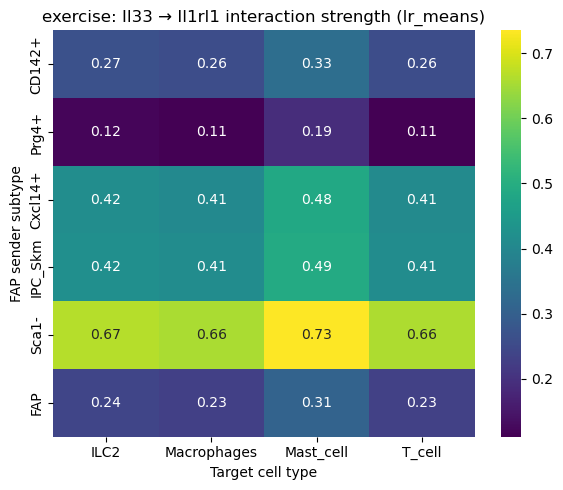

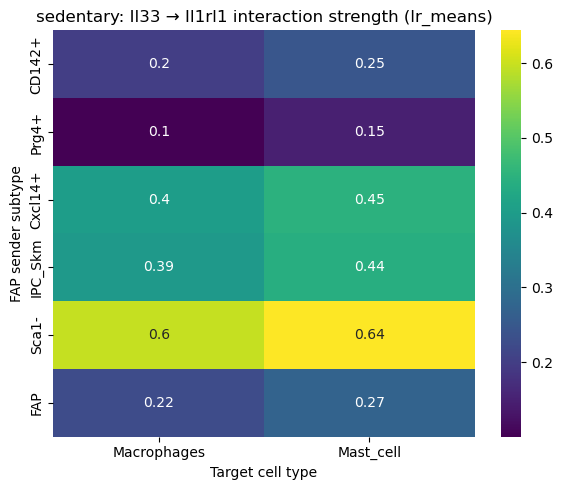

In [23]:
for cond in ["exercise", "sedentary"]:
    sub = il33_all[il33_all["condition"] == cond].copy()
    
    heat = sub.pivot_table(
        index="source",
        columns="target",
        values="lr_means",
        aggfunc="mean"
    )
    
    heat = heat.reindex(fap_types)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(heat, annot=True, cmap="viridis")
    plt.title(f"{cond}: Il33 → Il1rl1 interaction strength (lr_means)")
    plt.xlabel("Target cell type")
    plt.ylabel("FAP sender subtype")
    plt.tight_layout()
    plt.show()

In [24]:
compare_df = il33_all.pivot_table(
    index=["source", "target"],
    columns="condition",
    values="lr_means",
    aggfunc="mean"
).reset_index()

compare_df["delta_ex_minus_sed"] = compare_df["exercise"].fillna(0) - compare_df["sedentary"].fillna(0)

print(compare_df.sort_values("delta_ex_minus_sed", ascending=False))

condition   source       target  exercise  sedentary  delta_ex_minus_sed
20           Sca1-         ILC2  0.666110        NaN            0.666110
23           Sca1-       T_cell  0.657799        NaN            0.657799
12         IPC_Skm         ILC2  0.420519        NaN            0.420519
4          Cxcl14+         ILC2  0.415504        NaN            0.415504
15         IPC_Skm       T_cell  0.412207        NaN            0.412207
7          Cxcl14+       T_cell  0.407193        NaN            0.407193
0           CD142+         ILC2  0.265482        NaN            0.265482
3           CD142+       T_cell  0.257171        NaN            0.257171
8              FAP         ILC2  0.239748        NaN            0.239748
11             FAP       T_cell  0.231437        NaN            0.231437
16           Prg4+         ILC2  0.120848        NaN            0.120848
19           Prg4+       T_cell  0.112537        NaN            0.112537
22           Sca1-    Mast_cell  0.734944   0.64385

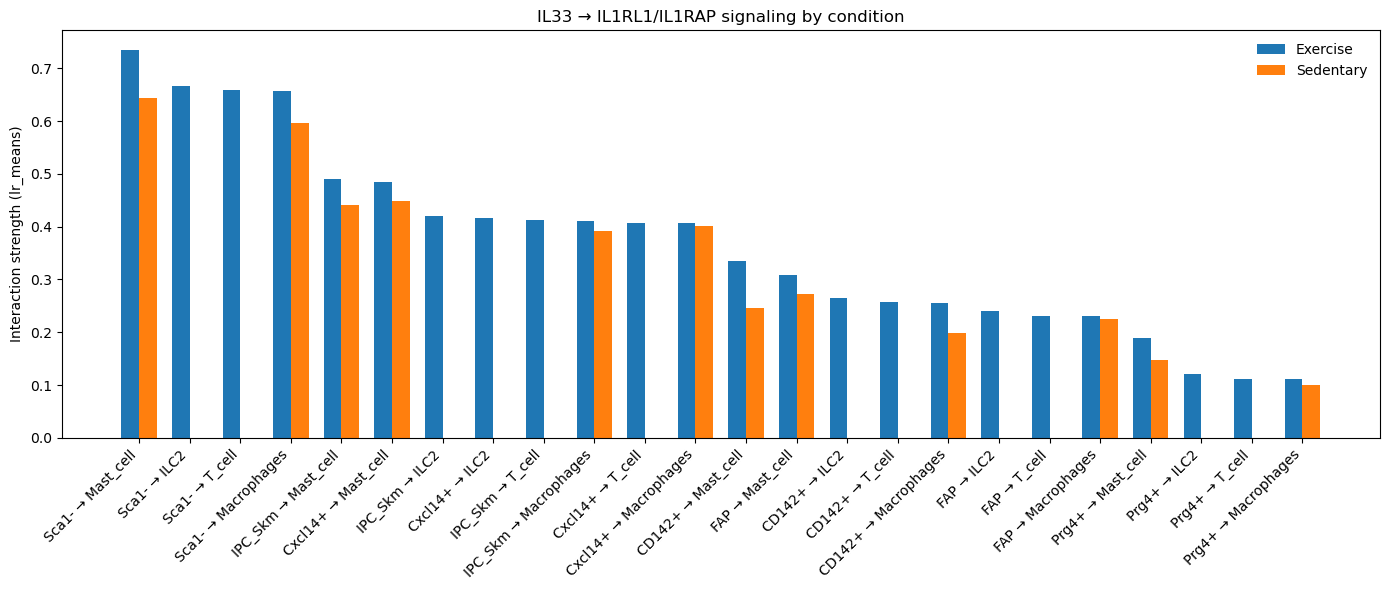

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Assume il33_all was already made using the CORRECT filter:
# ligand == "Il33" and receptor_complex contains both Il1rl1 and Il1rap
# -----------------------------

# Prepare data
compare_df = il33_all.pivot_table(
    index=["source", "target"],
    columns="condition",
    values="lr_means",
    aggfunc="mean"
).reset_index()

# Fill missing values
compare_df["exercise"] = compare_df["exercise"].fillna(0)
compare_df["sedentary"] = compare_df["sedentary"].fillna(0)

# Pair labels
compare_df["pair"] = compare_df["source"] + " → " + compare_df["target"]
compare_df["delta"] = compare_df["exercise"] - compare_df["sedentary"]

# Sort by exercise strength
compare_df = compare_df.sort_values(
    by="exercise",
    ascending=False
).reset_index(drop=True)

# Plot
x = np.arange(len(compare_df))
width = 0.35

plt.figure(figsize=(14, 6))
blue = "#1f77b4"
orange = "#ff7f0e"

plt.bar(x - width/2, compare_df["exercise"], width, color=blue, label="Exercise")
plt.bar(x + width/2, compare_df["sedentary"], width, color=orange, label="Sedentary")

plt.xticks(x, compare_df["pair"], rotation=45, ha="right")
plt.ylabel("Interaction strength (lr_means)")
plt.title("IL33 → IL1RL1/IL1RAP signaling by condition")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Exercise Il15 rows: 9
Sedentary Il15 rows: 0
condition       source target  exercise  sedentary     delta
0          Neutrophils   ILC2  0.180638          0  0.180638
1            Mast_cell   ILC2  0.144671          0  0.144671
2              Cxcl14+   ILC2  0.125670          0  0.125670
3                  FAP   ILC2  0.115294          0  0.115294
4              IPC_Skm   ILC2  0.079792          0  0.079792
5                Prg4+   ILC2  0.070978          0  0.070978
6               CD142+   ILC2  0.065621          0  0.065621
7                Sca1-   ILC2  0.059625          0  0.059625
8          Macrophages   ILC2  0.044783          0  0.044783


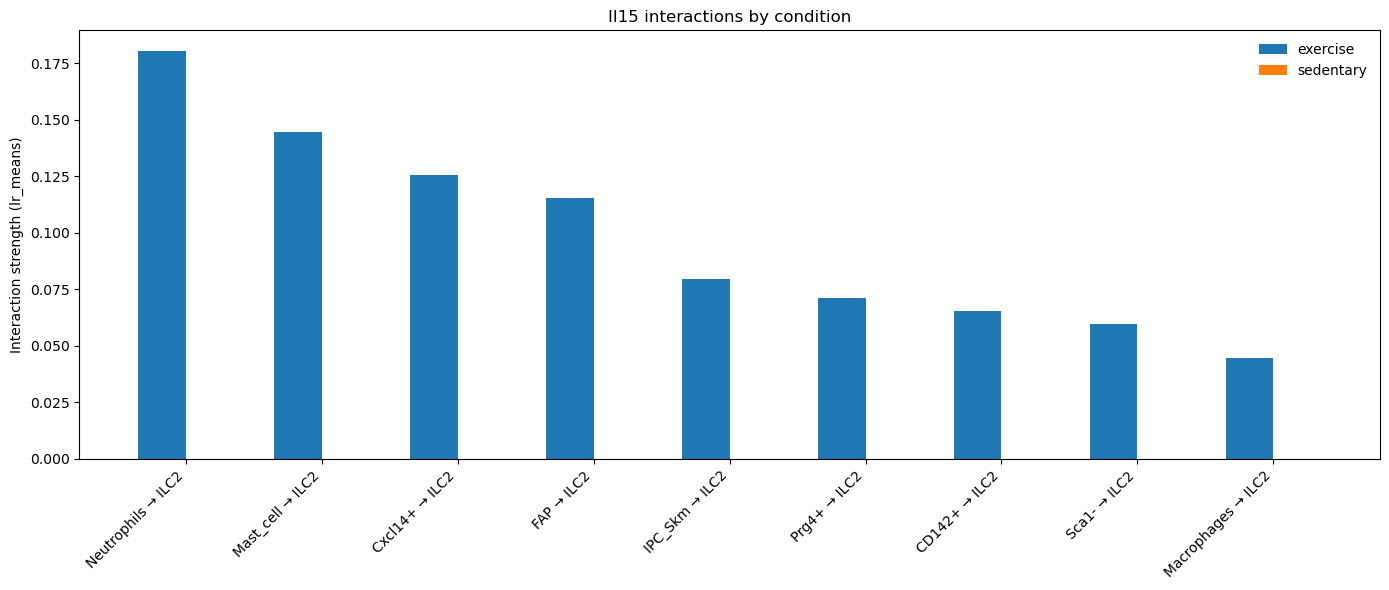

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# 1. Filter LIANA results for Il15
# --------------------------
il15_ex = lr_ex[
    (lr_ex["ligand"] == "Il15") &
    (lr_ex["receptor"] == "Il15ra")
].copy()

il15_sed = lr_sed[
    (lr_sed["ligand"] == "Il15") &
    (lr_sed["receptor"] == "Il15ra")
].copy()

il15_ex["condition"] = "exercise"
il15_sed["condition"] = "sedentary"

# Combine
il15_all = pd.concat([il15_ex, il15_sed], ignore_index=True)

print("Exercise Il15 rows:", il15_ex.shape[0])
print("Sedentary Il15 rows:", il15_sed.shape[0])

# --------------------------
# 2. Keep strongest interaction per source-target-condition
#    in case multiple Il15 receptor-related entries exist
# --------------------------
il15_all = (
    il15_all.sort_values("lr_means", ascending=False)
    .drop_duplicates(subset=["source", "target", "condition"])
    .copy()
)

# --------------------------
# 3. Pivot lr_means into exercise/sedentary columns
# --------------------------
compare_df = (
    il15_all.pivot_table(
        index=["source", "target"],
        columns="condition",
        values="lr_means",
        aggfunc="first"
    )
    .reset_index()
)

# Make sure both columns exist
if "exercise" not in compare_df.columns:
    compare_df["exercise"] = 0
if "sedentary" not in compare_df.columns:
    compare_df["sedentary"] = 0

compare_df["exercise"] = compare_df["exercise"].fillna(0)
compare_df["sedentary"] = compare_df["sedentary"].fillna(0)

# --------------------------
# 4. Labels
# --------------------------
compare_df["pair"] = compare_df["source"] + " → " + compare_df["target"]
compare_df["delta"] = compare_df["exercise"] - compare_df["sedentary"]

# --------------------------
# 5. Order target groups
# --------------------------
target_order = {
    "ILC2": 0,
    "T_cell": 1,
    "T cells": 1,
    "Macrophages": 2,
    "Neutrophils": 3,
    "Mast_cell": 4
}

compare_df["target_rank"] = compare_df["target"].map(target_order).fillna(99)

compare_df = compare_df.sort_values(
    by=["target_rank", "exercise"],
    ascending=[True, False]
).reset_index(drop=True)

print(compare_df[["source", "target", "exercise", "sedentary", "delta"]])

# --------------------------
# 6. Plot
# --------------------------
x = np.arange(len(compare_df))
width = 0.35

plt.figure(figsize=(14, 6))
blue = "#1f77b4"
orange = "#ff7f0e"

plt.bar(x - width/2, compare_df["exercise"], width, color=blue, label="exercise")
plt.bar(x + width/2, compare_df["sedentary"], width, color=orange, label="sedentary")

# separator lines between target groups
target_changes = compare_df["target"].ne(compare_df["target"].shift()).to_numpy()
group_starts = np.where(target_changes)[0]

for idx in group_starts[1:]:
    plt.axvline(idx - 0.5, color="gray", linestyle="--", alpha=0.6)

plt.xticks(x, compare_df["pair"], rotation=45, ha="right")
plt.ylabel("Interaction strength (lr_means)")
plt.title("Il15 interactions by condition")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

       exercise  sedentary      pval     padj sig
Il2rg  0.888889   0.803922  0.290571  0.57294  ns
Il2rb  0.587302   0.529412  0.572940  0.57294  ns


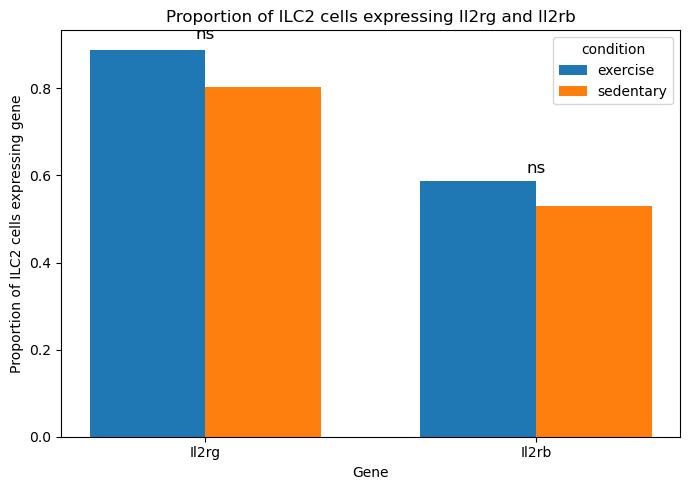

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# -----------------------------
# SETTINGS
# -----------------------------
celltype_col = "celltype"
condition_col = "condition"
ilc2_label = "ILC2"
genes = ["Il2rg", "Il2rb"]

# -----------------------------
# SUBSET TO ILC2
# -----------------------------
adata_ilc2 = adata_immune[adata_immune.obs[celltype_col] == ilc2_label].copy()

# -----------------------------
# BUILD DATAFRAME
# -----------------------------
df = pd.DataFrame({
    "condition": adata_ilc2.obs[condition_col].values
})

for gene in genes:
    x = adata_ilc2[:, gene].X
    if hasattr(x, "toarray"):
        x = x.toarray()
    df[gene] = np.ravel(x)

# binary expression
for gene in genes:
    df[f"{gene}_pos"] = df[gene] > 0

# -----------------------------
# CALCULATE PROPORTIONS
# -----------------------------
prop_df = (
    df.groupby("condition")[[f"{g}_pos" for g in genes]]
    .mean()
    .T
)

prop_df.columns = prop_df.columns.astype(str)
prop_df.index = genes

# -----------------------------
# STATISTICS
# -----------------------------
pvals = []

for gene in genes:
    ex = df.loc[df["condition"] == "exercise", f"{gene}_pos"]
    sed = df.loc[df["condition"] == "sedentary", f"{gene}_pos"]

    table = np.array([
        [ex.sum(), (~ex).sum()],
        [sed.sum(), (~sed).sum()]
    ])

    _, p = fisher_exact(table)
    pvals.append(p)

padj = multipletests(pvals, method="fdr_bh")[1]

stats_df = pd.DataFrame({
    "gene": genes,
    "pval": pvals,
    "padj": padj
}).set_index("gene")

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

stats_df["sig"] = stats_df["padj"].apply(p_to_star)

results = prop_df.join(stats_df)
print(results)

# -----------------------------
# PLOT
# -----------------------------
x = np.arange(len(genes))
width = 0.35

blue = "#1f77b4"
orange = "#ff7f0e"

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, results["exercise"], width, color=blue, label="exercise")
plt.bar(x + width/2, results["sedentary"], width, color=orange, label="sedentary")

# stars
ymax = np.maximum(results["exercise"], results["sedentary"])
for i, gene in enumerate(genes):
    y = ymax.iloc[i]
    offset = y * 0.02 if y > 0 else 0.01
    plt.text(i, y + offset, results.loc[gene, "sig"], ha="center", va="bottom", fontsize=12)

plt.xticks(x, genes)
plt.ylabel("Proportion of ILC2 cells expressing gene")
plt.xlabel("Gene")
plt.title("Proportion of ILC2 cells expressing Il2rg and Il2rb")
plt.legend(title="condition")
plt.tight_layout()
plt.show()

Exercise immune→immune IL15 rows: 3
Sedentary immune→immune IL15 rows: 0
        source target  exercise  sedentary  cellphone_pvals
0  Neutrophils   ILC2  0.180638          0            0.665
1    Mast_cell   ILC2  0.144671          0            0.767
2  Macrophages   ILC2  0.044783          0            1.000


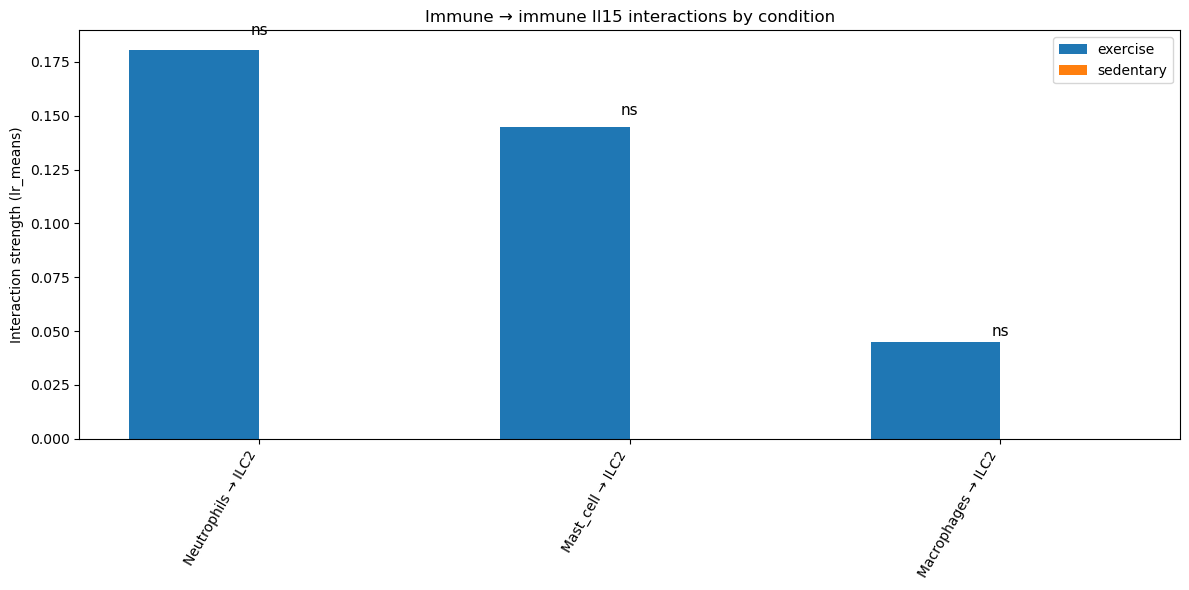

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# 1. Define immune cell types
#    Edit these to match your labels exactly
# --------------------------
immune_cells = ["Macrophages", "Neutrophils", "T_cell", "B_cell", "ILC2", "Mast_cell", "NK_cell"]

# --------------------------
# 2. Filter IL15 interactions in each condition
#    Include both simple Il15ra and receptor complexes containing Il15ra
# --------------------------
il15_ex = lr_ex[
    (lr_ex["ligand"] == "Il15") &
    (
        (lr_ex["receptor"] == "Il15ra") |
        (lr_ex["receptor_complex"].fillna("").str.contains("Il15ra", case=False))
    ) &
    (lr_ex["source"].isin(immune_cells)) &
    (lr_ex["target"].isin(immune_cells))
].copy()

il15_sed = lr_sed[
    (lr_sed["ligand"] == "Il15") &
    (
        (lr_sed["receptor"] == "Il15ra") |
        (lr_sed["receptor_complex"].fillna("").str.contains("Il15ra", case=False))
    ) &
    (lr_sed["source"].isin(immune_cells)) &
    (lr_sed["target"].isin(immune_cells))
].copy()

il15_ex["condition"] = "exercise"
il15_sed["condition"] = "sedentary"

print("Exercise immune→immune IL15 rows:", il15_ex.shape[0])
print("Sedentary immune→immune IL15 rows:", il15_sed.shape[0])

# --------------------------
# 3. Combine
# --------------------------
il15_all = pd.concat([il15_ex, il15_sed], ignore_index=True)

# Keep strongest interaction per source-target-condition
il15_all = (
    il15_all.sort_values("lr_means", ascending=False)
    .drop_duplicates(subset=["source", "target", "condition"])
    .copy()
)

# --------------------------
# 4. Pivot for comparison
# --------------------------
compare_df = (
    il15_all.pivot_table(
        index=["source", "target"],
        columns="condition",
        values="lr_means",
        aggfunc="first"
    )
    .reset_index()
)

if "exercise" not in compare_df.columns:
    compare_df["exercise"] = 0
if "sedentary" not in compare_df.columns:
    compare_df["sedentary"] = 0

compare_df["exercise"] = compare_df["exercise"].fillna(0)
compare_df["sedentary"] = compare_df["sedentary"].fillna(0)

# Add p-values
pvals = (
    il15_all.groupby(["source", "target"])["cellphone_pvals"]
    .min()
    .reset_index()
)

compare_df = compare_df.merge(pvals, on=["source", "target"], how="left")

# Labels
compare_df["pair"] = compare_df["source"] + " → " + compare_df["target"]
compare_df["delta"] = compare_df["exercise"] - compare_df["sedentary"]

def p_to_star(p):
    if pd.isna(p):
        return "ns"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

compare_df["sig"] = compare_df["cellphone_pvals"].apply(p_to_star)

# Sort by strongest exercise interaction
compare_df = compare_df.sort_values(
    by=["exercise", "sedentary"],
    ascending=[False, False]
).reset_index(drop=True)

print(compare_df[["source", "target", "exercise", "sedentary", "cellphone_pvals"]])

# --------------------------
# 5. Plot
# --------------------------
x = np.arange(len(compare_df))
width = 0.35

plt.figure(figsize=(max(12, len(compare_df) * 0.6), 6))
blue = "#1f77b4"
orange = "#ff7f0e"

plt.bar(x - width/2, compare_df["exercise"], width, color=blue, label="exercise")
plt.bar(x + width/2, compare_df["sedentary"], width, color=orange, label="sedentary")

# significance stars
ymax = np.maximum(compare_df["exercise"], compare_df["sedentary"])
for i in range(len(compare_df)):
    y = ymax.iloc[i]
    offset = y * 0.03 if y > 0 else 0.01
    plt.text(i, y + offset, compare_df["sig"].iloc[i],
             ha="center", va="bottom", fontsize=11)

plt.xticks(x, compare_df["pair"], rotation=60, ha="right")
plt.ylabel("Interaction strength (lr_means)")
plt.title("Immune → immune Il15 interactions by condition")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# Keep ALL interactions where target is ILC2
ilc2_ex = lr_ex[lr_ex["target"] == "ILC2"].copy()
ilc2_sed = lr_sed[lr_sed["target"] == "ILC2"].copy()

ilc2_ex["condition"] = "exercise"
ilc2_sed["condition"] = "sedentary"

ilc2_all = pd.concat([ilc2_ex, ilc2_sed], ignore_index=True)

print(ilc2_all.head())

   ligand ligand_complex  ligand_means  ligand_props receptor  \
0  Col1a2         Col1a2      3.537402      1.000000     Cd44   
1     Vim            Vim      3.482939      1.000000     Cd44   
2  Col1a2         Col1a2      3.537402      1.000000    Itgb3   
3     Vim            Vim      3.250633      0.999698     Cd44   
4     Vim            Vim      3.240166      0.998577     Cd44   

  receptor_complex  receptor_means  receptor_props   source target  lr_means  \
0             Cd44        0.249349        0.873016   CD142+   ILC2  1.893376   
1             Cd44        0.249349        0.873016    Prg4+   ILC2  1.866144   
2            Itgb3        0.051899        0.222222   CD142+   ILC2  1.794650   
3             Cd44        0.249349        0.873016  IPC_Skm   ILC2  1.749991   
4             Cd44        0.249349        0.873016   CD142+   ILC2  1.744758   

   cellphone_pvals condition  
0            0.028  exercise  
1            0.071  exercise  
2            0.000  exercise  
3   

In [32]:
summary = (
    ilc2_all
    .groupby(["source", "condition"])["lr_means"]
    .sum()
    .unstack()
    .fillna(0)
    .reset_index()
)

summary["delta"] = summary["exercise"] - summary["sedentary"]

summary = summary.sort_values("exercise", ascending=False)

print(summary)

condition       source    exercise   sedentary      delta
4              Cxcl14+  148.150238  131.386307  16.763931
1               CD142+  140.418396  120.839088  19.579308
7              IPC_Skm  138.505661  120.833885  17.671776
13               Sca1-  133.955566  116.746910  17.208656
12               Prg4+  128.065887  112.109573  15.956314
5                  FAP  119.113380  111.388496   7.724884
8          Macrophages   20.685968   19.186584   1.499384
11         Neutrophils   19.587072   17.695879   1.891193
9            Mast_cell   17.033144   18.514751  -1.481607
14              T_cell   14.562406   11.823732   2.738673
10             NK_cell   13.988974   11.485081   2.503893
6                 ILC2   13.761142   12.725931   1.035211
2            CD4_Tcell   12.335487    9.605255   2.730232
3            CD8_Tcell   11.474541    8.698076   2.776464
0               B_Cell   11.385970    9.663080   1.722890


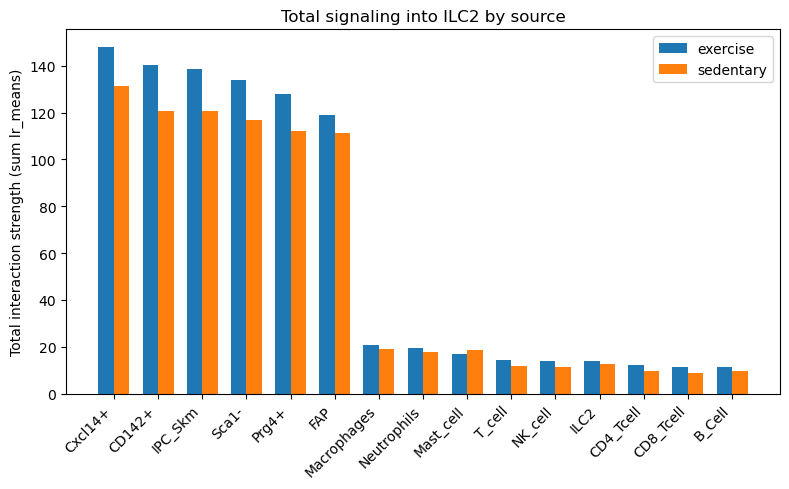

In [33]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = summary.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, plot_df["exercise"], width, label="exercise")
plt.bar(x + width/2, plot_df["sedentary"], width, label="sedentary")

plt.xticks(x, plot_df["source"], rotation=45, ha="right")
plt.ylabel("Total interaction strength (sum lr_means)")
plt.title("Total signaling into ILC2 by source")

plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# Get top changing interactions into ILC2
pivot_lr = ilc2_all.pivot_table(
    index=["source", "ligand", "receptor"],
    columns="condition",
    values="lr_means",
    aggfunc="mean"
).reset_index()

pivot_lr["exercise"] = pivot_lr["exercise"].fillna(0)
pivot_lr["sedentary"] = pivot_lr["sedentary"].fillna(0)

pivot_lr["delta"] = pivot_lr["exercise"] - pivot_lr["sedentary"]

# Top increases
top_up = pivot_lr.sort_values("delta", ascending=False).head(20)

# Top decreases
top_down = pivot_lr.sort_values("delta").head(20)

print("Top increased signaling into ILC2:")
print(top_up)

print("\nTop decreased signaling into ILC2:")
print(top_down)

Top increased signaling into ILC2:
condition   source  ligand receptor  exercise  sedentary     delta
1647       IPC_Skm   Mfap5   Notch1  1.446551        0.0  1.446551
2936         Sca1-   Hspa8    Adrb2  1.396281        0.0  1.396281
2818         Sca1-    Apoe     Lrp6  1.384864        0.0  1.384864
242         CD142+    Gnas    Adcy7  1.357332        0.0  1.357332
2598         Prg4+    Gnas    Adcy7  1.355488        0.0  1.355488
244         CD142+    Gnas    Adrb2  1.331236        0.0  1.331236
834        Cxcl14+   Hspa8    Adrb2  1.330066        0.0  1.330066
2600         Prg4+    Gnas    Adrb2  1.329392        0.0  1.329392
818        Cxcl14+    Gnas    Adcy7  1.324817        0.0  1.324817
1574       IPC_Skm    Gnas    Adcy7  1.313383        0.0  1.313383
820        Cxcl14+    Gnas    Adrb2  1.298721        0.0  1.298721
1587       IPC_Skm   Hspa8    Adrb2  1.293832        0.0  1.293832
1576       IPC_Skm    Gnas    Adrb2  1.287287        0.0  1.287287
2614         Prg4+   Hspa8 

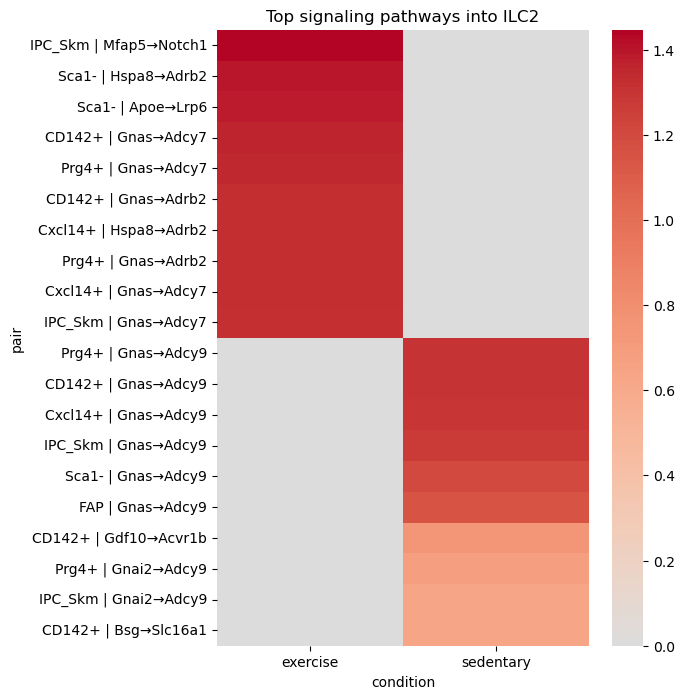

In [47]:
import seaborn as sns

top_pairs = pd.concat([
    top_up.head(10),
    top_down.head(10)
])

top_pairs["pair"] = top_pairs["source"] + " | " + top_pairs["ligand"] + "→" + top_pairs["receptor"]

heatmap_df = top_pairs.set_index("pair")[["exercise", "sedentary"]]

plt.figure(figsize=(6,8))
sns.heatmap(heatmap_df, cmap="coolwarm", center=0)
plt.title("Top signaling pathways into ILC2")
plt.show()

             exercise  sedentary          pval      padj  sig
celltype                                                     
B_Cell       0.000000   0.003013  3.172976e-01  0.475946   ns
CD4_Tcell    0.002905   0.000000  1.428722e-01  0.257170   ns
CD8_Tcell    0.000000   0.003517  3.786038e-01  0.486776   ns
ILC2         0.009699   0.000000  1.183061e-01  0.257170   ns
Macrophages  0.050570   0.030170  5.321573e-02  0.159647   ns
Mast_cell    0.250348   0.153220  7.603899e-01  0.839654   ns
NK_cell      0.012108   0.013366  8.396543e-01  0.839654   ns
Neutrophils  0.322282   0.369850  2.021630e-07  0.000002  ***
T_cell       0.008899   0.000000  1.889954e-02  0.085048   ns


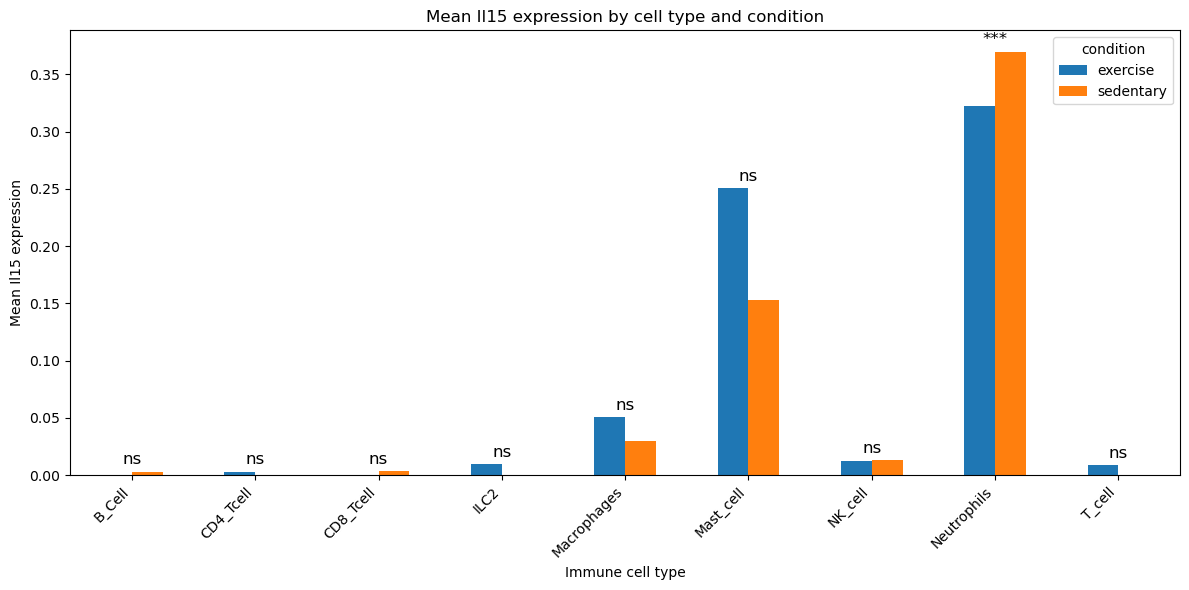

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Build dataframe
df = pd.DataFrame({
    "Il15": adata_immune[:, ["Il15"]].X.toarray().flatten(),
    "celltype": adata_immune.obs["celltype"].values,
    "condition": adata_immune.obs["condition"].values
})

# Mean expression table
mean_table = df.groupby(["celltype", "condition"])["Il15"].mean().unstack()

# Keep a consistent order
celltypes = mean_table.index.tolist()

# Statistical testing
pvals = []

for ct in celltypes:
    sub = df[df["celltype"] == ct]

    ex = sub[sub["condition"] == "exercise"]["Il15"]
    sed = sub[sub["condition"] == "sedentary"]["Il15"]

    if len(ex) > 0 and len(sed) > 0:
        _, p = mannwhitneyu(ex, sed, alternative="two-sided")
    else:
        p = np.nan

    pvals.append(p)

# Adjust p-values
valid_mask = ~np.isnan(pvals)
padj = np.full(len(pvals), np.nan)
padj[valid_mask] = multipletests(np.array(pvals)[valid_mask], method="fdr_bh")[1]

stats_df = pd.DataFrame({
    "celltype": celltypes,
    "pval": pvals,
    "padj": padj
}).set_index("celltype")

def p_to_star(p):
    if pd.isna(p):
        return "na"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

stats_df["sig"] = stats_df["padj"].apply(p_to_star)

results = mean_table.join(stats_df)
print(results)

# Plot
ax = mean_table[["exercise", "sedentary"]].plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Il15 expression")
plt.xlabel("Immune cell type")
plt.title("Mean Il15 expression by cell type and condition")
plt.xticks(rotation=45, ha="right")

# Add significance labels
ymax = mean_table.max(axis=1)
offset = ymax.max() * 0.01  # dynamic spacing

for i, ct in enumerate(mean_table.index):
    ax.text(i, ymax.loc[ct] + offset, results.loc[ct, "sig"],
            ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.show()

             exercise  sedentary      pval      padj sig
celltype                                                
B_Cell       0.000000   0.000000  1.000000  1.000000  ns
CD4_Tcell    0.001920   0.006923  0.567957  1.000000  ns
CD8_Tcell    0.003923   0.003675  0.853882  1.000000  ns
ILC2         0.038995   0.025454  0.248292  0.744875  ns
Macrophages  0.016511   0.014958  0.738251  1.000000  ns
Mast_cell    0.000000   0.000000  1.000000  1.000000  ns
NK_cell      0.011830   0.005993  0.112663  0.506982  ns
Neutrophils  0.008235   0.009818  0.753309  1.000000  ns
T_cell       0.015541   0.003886  0.067309  0.506982  ns


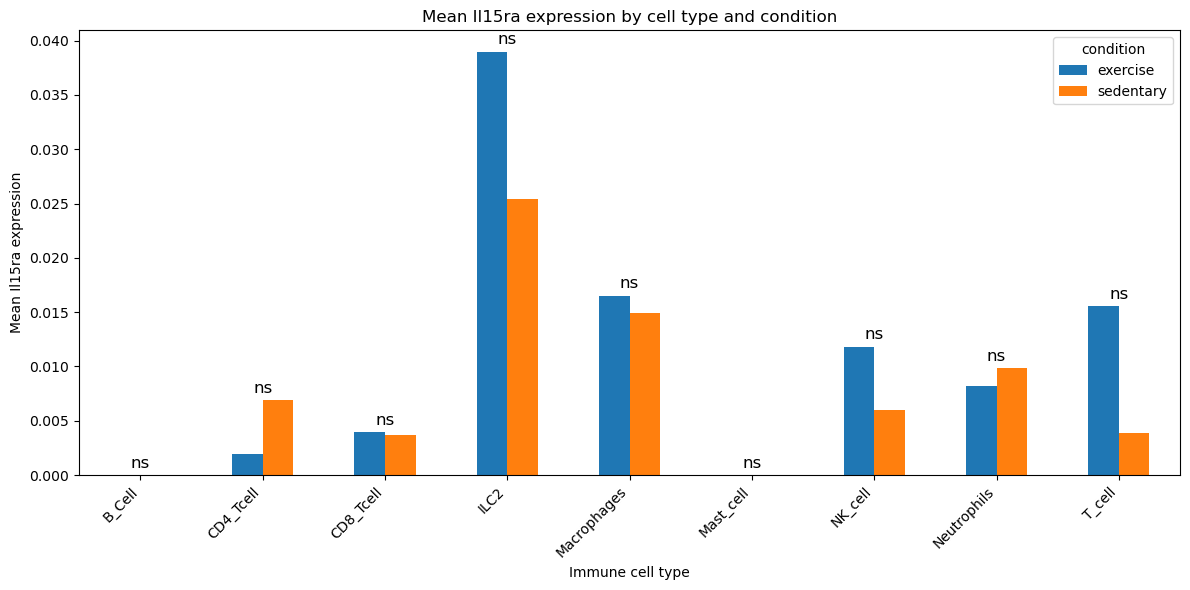

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Build dataframe
df = pd.DataFrame({
    "Il15ra": adata_immune[:, ["Il15ra"]].X.toarray().flatten(),
    "celltype": adata_immune.obs["celltype"].values,
    "condition": adata_immune.obs["condition"].values
})

# Mean expression table
mean_table = df.groupby(["celltype", "condition"])["Il15ra"].mean().unstack()

# Keep a consistent order
celltypes = mean_table.index.tolist()

# Statistical testing
pvals = []

for ct in celltypes:
    sub = df[df["celltype"] == ct]

    ex = sub[sub["condition"] == "exercise"]["Il15ra"]
    sed = sub[sub["condition"] == "sedentary"]["Il15ra"]

    if len(ex) > 0 and len(sed) > 0:
        _, p = mannwhitneyu(ex, sed, alternative="two-sided")
    else:
        p = np.nan

    pvals.append(p)

# Adjust p-values
valid_mask = ~np.isnan(pvals)
padj = np.full(len(pvals), np.nan)
padj[valid_mask] = multipletests(np.array(pvals)[valid_mask], method="fdr_bh")[1]

stats_df = pd.DataFrame({
    "celltype": celltypes,
    "pval": pvals,
    "padj": padj
}).set_index("celltype")

def p_to_star(p):
    if pd.isna(p):
        return "na"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

stats_df["sig"] = stats_df["padj"].apply(p_to_star)

results = mean_table.join(stats_df)
print(results)

# Plot
ax = mean_table[["exercise", "sedentary"]].plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Il15ra expression")
plt.xlabel("Immune cell type")
plt.title("Mean Il15ra expression by cell type and condition")
plt.xticks(rotation=45, ha="right")

# Add significance labels
ymax = mean_table.max(axis=1)
offset = ymax.max() * 0.01  # dynamic spacing

for i, ct in enumerate(mean_table.index):
    ax.text(i, ymax.loc[ct] + offset, results.loc[ct, "sig"],
            ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.show()

             exercise  sedentary          pval          padj  sig
celltype                                                         
B_Cell       0.000000   0.000000  1.000000e+00  1.000000e+00   ns
CD4_Tcell    0.127640   0.105158  4.888983e-01  7.333475e-01   ns
CD8_Tcell    0.016295   0.008106  1.766992e-01  4.552879e-01   ns
ILC2         0.153844   0.169032  2.289699e-01  4.552879e-01   ns
Macrophages  0.000000   0.001594  2.529377e-01  4.552879e-01   ns
Mast_cell    0.000000   0.000000  1.000000e+00  1.000000e+00   ns
NK_cell      0.298795   0.330330  1.058833e-09  9.529494e-09  ***
Neutrophils  0.000000   0.000000  1.000000e+00  1.000000e+00   ns
T_cell       0.180657   0.231220  7.192449e-05  3.236602e-04  ***


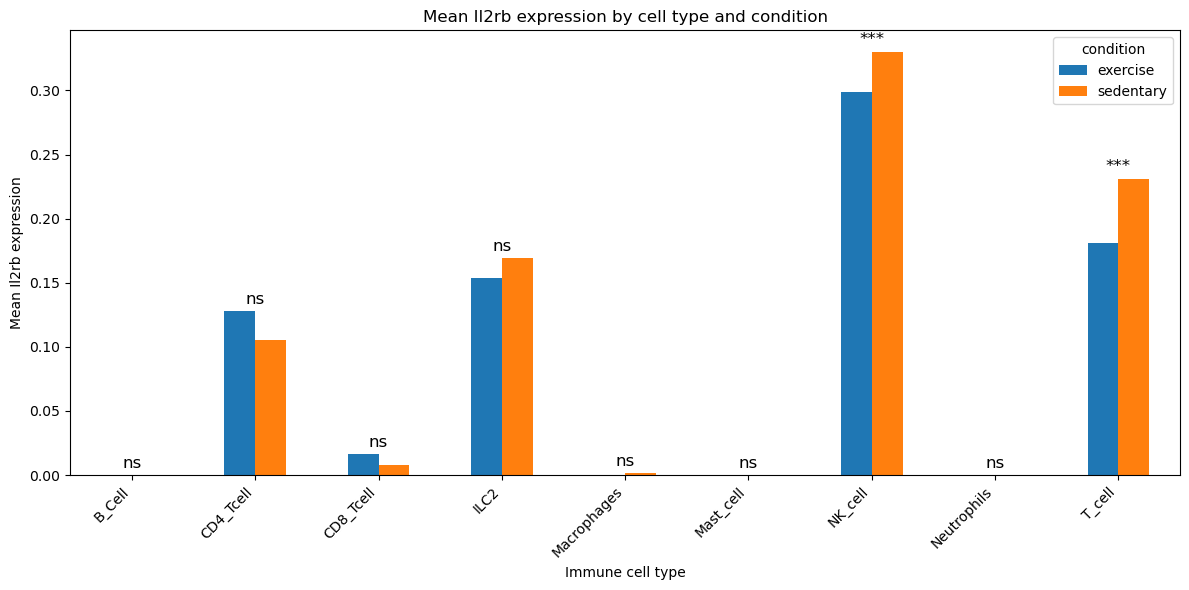

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Build dataframe
df = pd.DataFrame({
    "Il2rb": adata_immune[:, ["Il2rb"]].X.toarray().flatten(),
    "celltype": adata_immune.obs["celltype"].values,
    "condition": adata_immune.obs["condition"].values
})

# Mean expression table
mean_table = df.groupby(["celltype", "condition"])["Il2rb"].mean().unstack()

# Keep a consistent order
celltypes = mean_table.index.tolist()

# Statistical testing
pvals = []

for ct in celltypes:
    sub = df[df["celltype"] == ct]

    ex = sub[sub["condition"] == "exercise"]["Il2rb"]
    sed = sub[sub["condition"] == "sedentary"]["Il2rb"]

    if len(ex) > 0 and len(sed) > 0:
        _, p = mannwhitneyu(ex, sed, alternative="two-sided")
    else:
        p = np.nan

    pvals.append(p)

# Adjust p-values
valid_mask = ~np.isnan(pvals)
padj = np.full(len(pvals), np.nan)
padj[valid_mask] = multipletests(np.array(pvals)[valid_mask], method="fdr_bh")[1]

stats_df = pd.DataFrame({
    "celltype": celltypes,
    "pval": pvals,
    "padj": padj
}).set_index("celltype")

def p_to_star(p):
    if pd.isna(p):
        return "na"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

stats_df["sig"] = stats_df["padj"].apply(p_to_star)

results = mean_table.join(stats_df)
print(results)

# Plot
ax = mean_table[["exercise", "sedentary"]].plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Il2rb expression")
plt.xlabel("Immune cell type")
plt.title("Mean Il2rb expression by cell type and condition")
plt.xticks(rotation=45, ha="right")

# Add significance labels
ymax = mean_table.max(axis=1)
offset = ymax.max() * 0.01  # dynamic spacing

for i, ct in enumerate(mean_table.index):
    ax.text(i, ymax.loc[ct] + offset, results.loc[ct, "sig"],
            ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.show()

             exercise  sedentary      pval      padj sig
celltype                                                
B_Cell       0.224732   0.211146  0.245930  0.553342  ns
CD4_Tcell    0.202809   0.163533  0.711494  0.868446  ns
CD8_Tcell    0.180753   0.142212  0.732045  0.868446  ns
ILC2         0.243874   0.274215  0.000487  0.004384  **
Macrophages  0.052000   0.052758  0.771952  0.868446  ns
Mast_cell    0.275512   0.121684  0.160660  0.481979  ns
NK_cell      0.193617   0.146345  0.064801  0.291604  ns
Neutrophils  0.022466   0.035388  0.624885  0.868446  ns
T_cell       0.189446   0.165748  0.885459  0.885459  ns


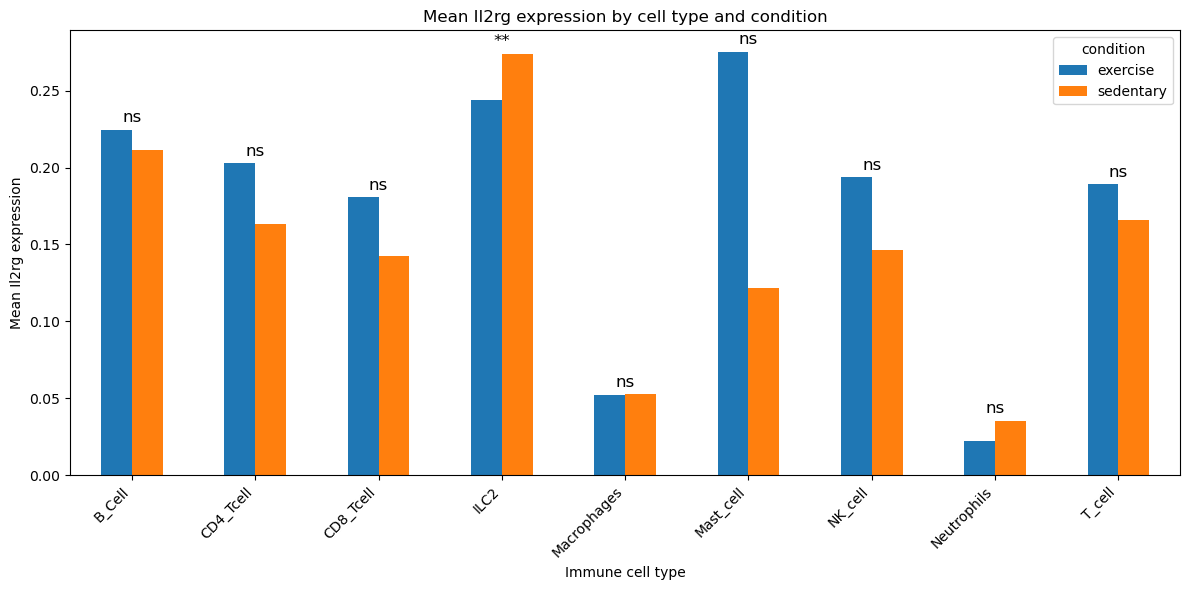

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Build dataframe
df = pd.DataFrame({
    "Il2rg": adata_immune[:, ["Il2rg"]].X.toarray().flatten(),
    "celltype": adata_immune.obs["celltype"].values,
    "condition": adata_immune.obs["condition"].values
})

# Mean expression table
mean_table = df.groupby(["celltype", "condition"])["Il2rg"].mean().unstack()

# Keep a consistent order
celltypes = mean_table.index.tolist()

# Statistical testing
pvals = []

for ct in celltypes:
    sub = df[df["celltype"] == ct]

    ex = sub[sub["condition"] == "exercise"]["Il2rg"]
    sed = sub[sub["condition"] == "sedentary"]["Il2rg"]

    if len(ex) > 0 and len(sed) > 0:
        _, p = mannwhitneyu(ex, sed, alternative="two-sided")
    else:
        p = np.nan

    pvals.append(p)

# Adjust p-values
valid_mask = ~np.isnan(pvals)
padj = np.full(len(pvals), np.nan)
padj[valid_mask] = multipletests(np.array(pvals)[valid_mask], method="fdr_bh")[1]

stats_df = pd.DataFrame({
    "celltype": celltypes,
    "pval": pvals,
    "padj": padj
}).set_index("celltype")

def p_to_star(p):
    if pd.isna(p):
        return "na"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

stats_df["sig"] = stats_df["padj"].apply(p_to_star)

results = mean_table.join(stats_df)
print(results)

# Plot
ax = mean_table[["exercise", "sedentary"]].plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Il2rg expression")
plt.xlabel("Immune cell type")
plt.title("Mean Il2rg expression by cell type and condition")
plt.xticks(rotation=45, ha="right")

# Add significance labels
ymax = mean_table.max(axis=1)
offset = ymax.max() * 0.01  # dynamic spacing

for i, ct in enumerate(mean_table.index):
    ax.text(i, ymax.loc[ct] + offset, results.loc[ct, "sig"],
            ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.show()

             exercise  sedentary      pval  padj sig
celltype                                            
B_Cell       0.000000   0.007353  0.496350   1.0  ns
CD4_Tcell    0.000000   0.000000  1.000000   1.0  ns
CD8_Tcell    0.000000   0.011696  1.000000   1.0  ns
ILC2         0.000000   0.000000  1.000000   1.0  ns
Macrophages  0.029851   0.039604  0.727948   1.0  ns
Mast_cell    0.714286   0.375000  0.314685   1.0  ns
NK_cell      0.029197   0.029126  1.000000   1.0  ns
Neutrophils  0.800000   0.732673  0.236679   1.0  ns
T_cell       0.000000   0.000000  1.000000   1.0  ns


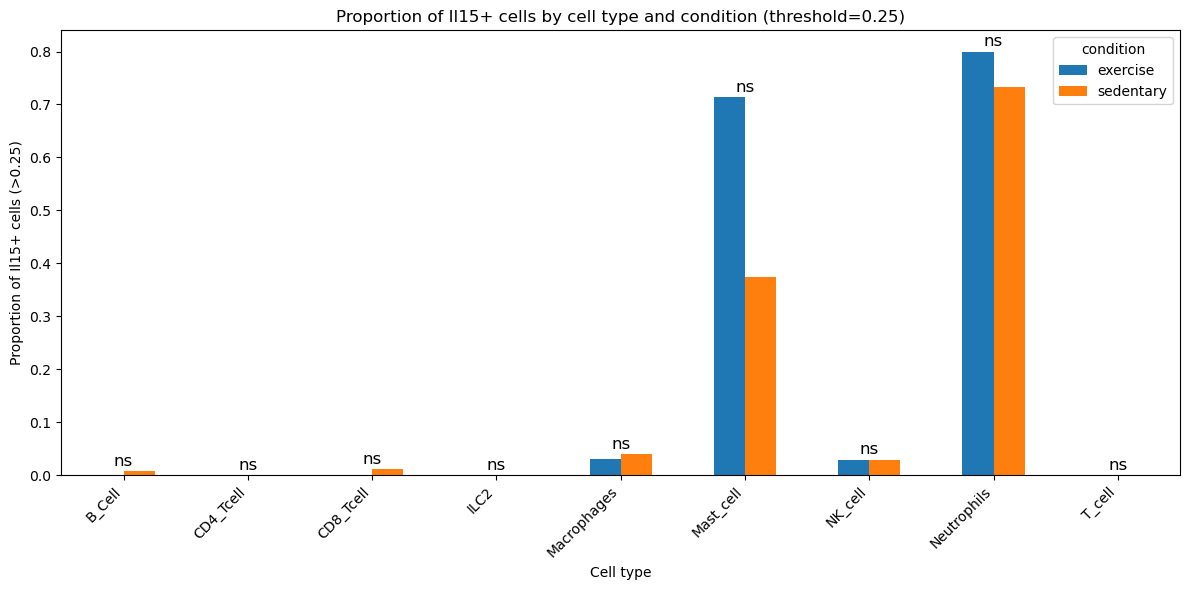

In [42]:
threshold = 0.25 # you can test 0.25, 0.5 as well

df = pd.DataFrame({
    "Il15": adata_immune[:, ["Il15"]].X.toarray().flatten(),
    "celltype": adata_immune.obs["celltype"].values,
    "condition": adata_immune.obs["condition"].values
})

df["Il15_pos"] = df["Il15"] > threshold

prop_table = df.groupby(["celltype", "condition"])["Il15_pos"].mean().unstack()
celltypes = prop_table.index.tolist()

pvals = []

for ct in celltypes:
    sub = df[df["celltype"] == ct]

    ex = sub[sub["condition"] == "exercise"]["Il15_pos"]
    sed = sub[sub["condition"] == "sedentary"]["Il15_pos"]

    table = np.array([
        [ex.sum(), (~ex).sum()],
        [sed.sum(), (~sed).sum()]
    ])

    if table.shape == (2, 2):
        _, p = fisher_exact(table)
    else:
        p = np.nan

    pvals.append(p)

valid_mask = ~np.isnan(pvals)
padj = np.full(len(pvals), np.nan)
padj[valid_mask] = multipletests(np.array(pvals)[valid_mask], method="fdr_bh")[1]

stats_df = pd.DataFrame({
    "celltype": celltypes,
    "pval": pvals,
    "padj": padj
}).set_index("celltype")

def p_to_star(p):
    if pd.isna(p):
        return "na"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

stats_df["sig"] = stats_df["padj"].apply(p_to_star)

results = prop_table.join(stats_df)
print(results)

ax = prop_table[["exercise", "sedentary"]].plot(kind="bar", figsize=(12, 6))
plt.ylabel(f"Proportion of Il15+ cells (>{threshold})")
plt.xlabel("Cell type")
plt.title(f"Proportion of Il15+ cells by cell type and condition (threshold={threshold})")
plt.xticks(rotation=45, ha="right")

ymax = prop_table.max(axis=1)
offset = ymax.max() * 0.005

for i, ct in enumerate(prop_table.index):
    ax.text(i, ymax.loc[ct] + offset, results.loc[ct, "sig"],
            ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.show()

             exercise  sedentary      pval  padj sig
celltype                                            
B_Cell       0.000000   0.000000  1.000000   1.0  ns
CD4_Tcell    0.000000   0.018405  0.553678   1.0  ns
CD8_Tcell    0.014925   0.011696  1.000000   1.0  ns
ILC2         0.047619   0.058824  1.000000   1.0  ns
Macrophages  0.007463   0.009901  1.000000   1.0  ns
Mast_cell    0.000000   0.000000  1.000000   1.0  ns
NK_cell      0.021898   0.019417  1.000000   1.0  ns
Neutrophils  0.015789   0.019802  1.000000   1.0  ns
T_cell       0.010526   0.000000  0.479798   1.0  ns


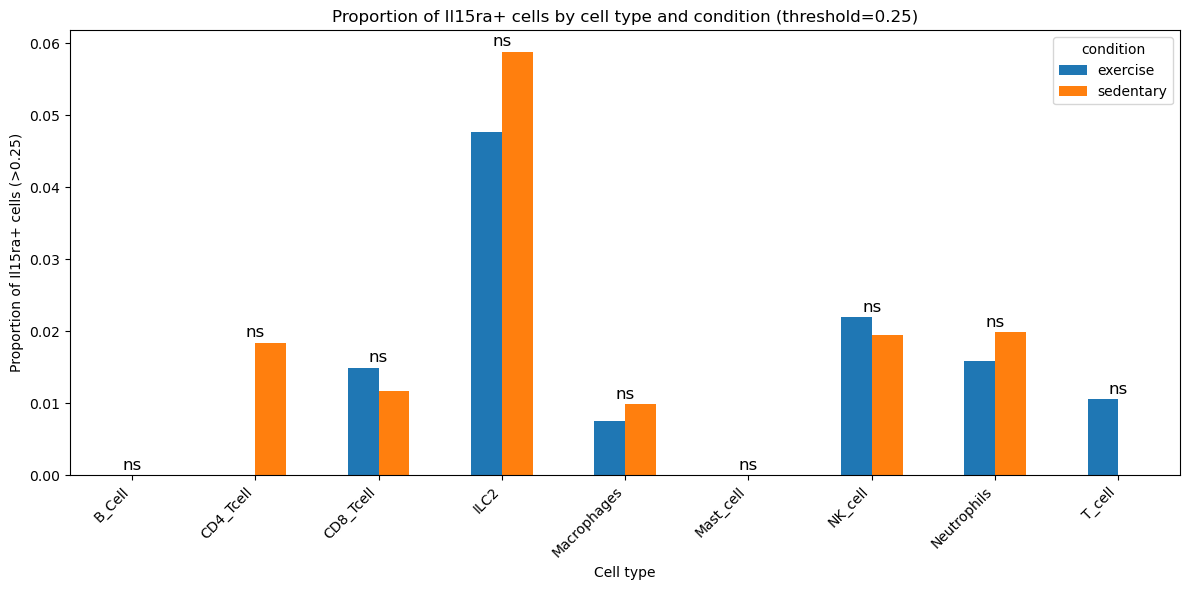

In [39]:
threshold = 0.25 # you can test 0.25, 0.5 as well

df = pd.DataFrame({
    "Il15ra": adata_immune[:, ["Il15ra"]].X.toarray().flatten(),
    "celltype": adata_immune.obs["celltype"].values,
    "condition": adata_immune.obs["condition"].values
})

df["Il15ra_pos"] = df["Il15ra"] > threshold

prop_table = df.groupby(["celltype", "condition"])["Il15ra_pos"].mean().unstack()
celltypes = prop_table.index.tolist()

pvals = []

for ct in celltypes:
    sub = df[df["celltype"] == ct]

    ex = sub[sub["condition"] == "exercise"]["Il15ra_pos"]
    sed = sub[sub["condition"] == "sedentary"]["Il15ra_pos"]

    table = np.array([
        [ex.sum(), (~ex).sum()],
        [sed.sum(), (~sed).sum()]
    ])

    if table.shape == (2, 2):
        _, p = fisher_exact(table)
    else:
        p = np.nan

    pvals.append(p)

valid_mask = ~np.isnan(pvals)
padj = np.full(len(pvals), np.nan)
padj[valid_mask] = multipletests(np.array(pvals)[valid_mask], method="fdr_bh")[1]

stats_df = pd.DataFrame({
    "celltype": celltypes,
    "pval": pvals,
    "padj": padj
}).set_index("celltype")

def p_to_star(p):
    if pd.isna(p):
        return "na"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

stats_df["sig"] = stats_df["padj"].apply(p_to_star)

results = prop_table.join(stats_df)
print(results)

ax = prop_table[["exercise", "sedentary"]].plot(kind="bar", figsize=(12, 6))
plt.ylabel(f"Proportion of Il15ra+ cells (>{threshold})")
plt.xlabel("Cell type")
plt.title(f"Proportion of Il15ra+ cells by cell type and condition (threshold={threshold})")
plt.xticks(rotation=45, ha="right")

ymax = prop_table.max(axis=1)
offset = ymax.max() * 0.005

for i, ct in enumerate(prop_table.index):
    ax.text(i, ymax.loc[ct] + offset, results.loc[ct, "sig"],
            ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.show()

             exercise  sedentary      pval      padj  sig
celltype                                                 
B_Cell       0.000000   0.000000  1.000000  1.000000   ns
CD4_Tcell    0.133333   0.288344  0.009037  0.040669    *
CD8_Tcell    0.029851   0.023392  0.675132  1.000000   ns
ILC2         0.333333   0.490196  0.124322  0.372965   ns
Macrophages  0.000000   0.000000  1.000000  1.000000   ns
Mast_cell    0.000000   0.000000  1.000000  1.000000   ns
NK_cell      0.897810   0.912621  0.705933  1.000000   ns
Neutrophils  0.000000   0.000000  1.000000  1.000000   ns
T_cell       0.242105   0.553398  0.000012  0.000104  ***


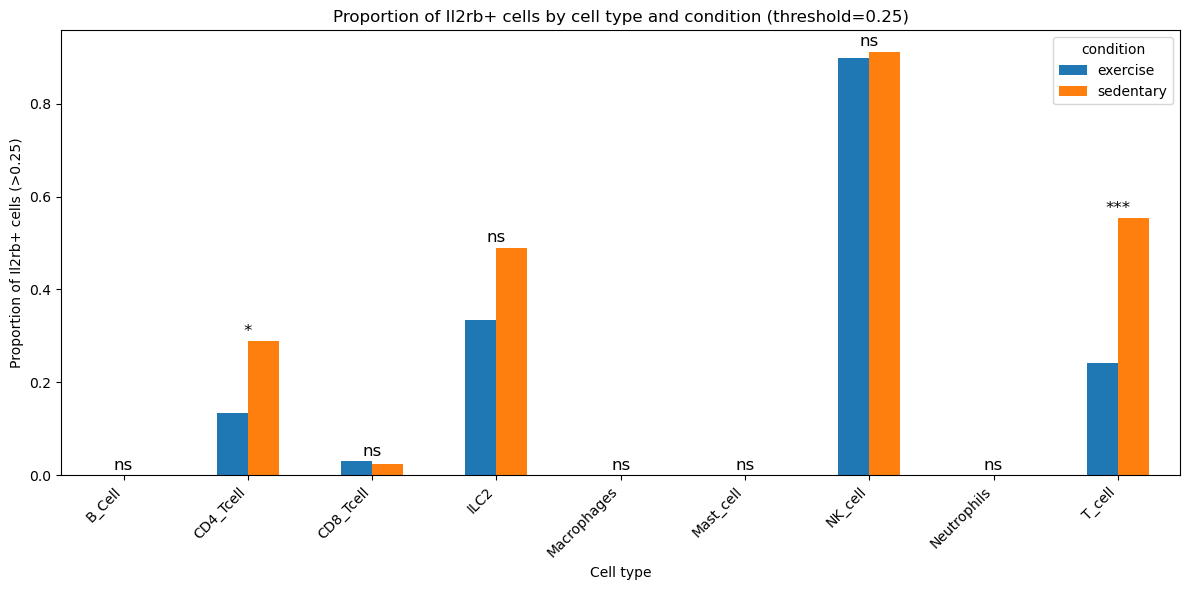

In [38]:
threshold = 0.25 # you can test 0.25, 0.5 as well

df = pd.DataFrame({
    "Il2rb": adata_immune[:, ["Il2rb"]].X.toarray().flatten(),
    "celltype": adata_immune.obs["celltype"].values,
    "condition": adata_immune.obs["condition"].values
})

df["Il2rb_pos"] = df["Il2rb"] > threshold

prop_table = df.groupby(["celltype", "condition"])["Il2rb_pos"].mean().unstack()
celltypes = prop_table.index.tolist()

pvals = []

for ct in celltypes:
    sub = df[df["celltype"] == ct]

    ex = sub[sub["condition"] == "exercise"]["Il2rb_pos"]
    sed = sub[sub["condition"] == "sedentary"]["Il2rb_pos"]

    table = np.array([
        [ex.sum(), (~ex).sum()],
        [sed.sum(), (~sed).sum()]
    ])

    if table.shape == (2, 2):
        _, p = fisher_exact(table)
    else:
        p = np.nan

    pvals.append(p)

valid_mask = ~np.isnan(pvals)
padj = np.full(len(pvals), np.nan)
padj[valid_mask] = multipletests(np.array(pvals)[valid_mask], method="fdr_bh")[1]

stats_df = pd.DataFrame({
    "celltype": celltypes,
    "pval": pvals,
    "padj": padj
}).set_index("celltype")

def p_to_star(p):
    if pd.isna(p):
        return "na"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

stats_df["sig"] = stats_df["padj"].apply(p_to_star)

results = prop_table.join(stats_df)
print(results)

ax = prop_table[["exercise", "sedentary"]].plot(kind="bar", figsize=(12, 6))
plt.ylabel(f"Proportion of Il2rb+ cells (>{threshold})")
plt.xlabel("Cell type")
plt.title(f"Proportion of Il2rb+ cells by cell type and condition (threshold={threshold})")
plt.xticks(rotation=45, ha="right")

ymax = prop_table.max(axis=1)
offset = ymax.max() * 0.005

for i, ct in enumerate(prop_table.index):
    ax.text(i, ymax.loc[ct] + offset, results.loc[ct, "sig"],
            ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.show()

             exercise  sedentary      pval      padj sig
celltype                                                
B_Cell       0.608696   0.536765  0.271717  0.409904  ns
CD4_Tcell    0.346667   0.423313  0.318814  0.409904  ns
CD8_Tcell    0.507463   0.426901  0.310774  0.409904  ns
ILC2         0.682540   0.764706  0.403725  0.454191  ns
Macrophages  0.022388   0.049505  0.294345  0.409904  ns
Mast_cell    0.857143   0.250000  0.040559  0.121678  ns
NK_cell      0.510949   0.393204  0.035146  0.121678  ns
Neutrophils  0.057895   0.069307  0.799124  0.799124  ns
T_cell       0.200000   0.349515  0.025792  0.121678  ns


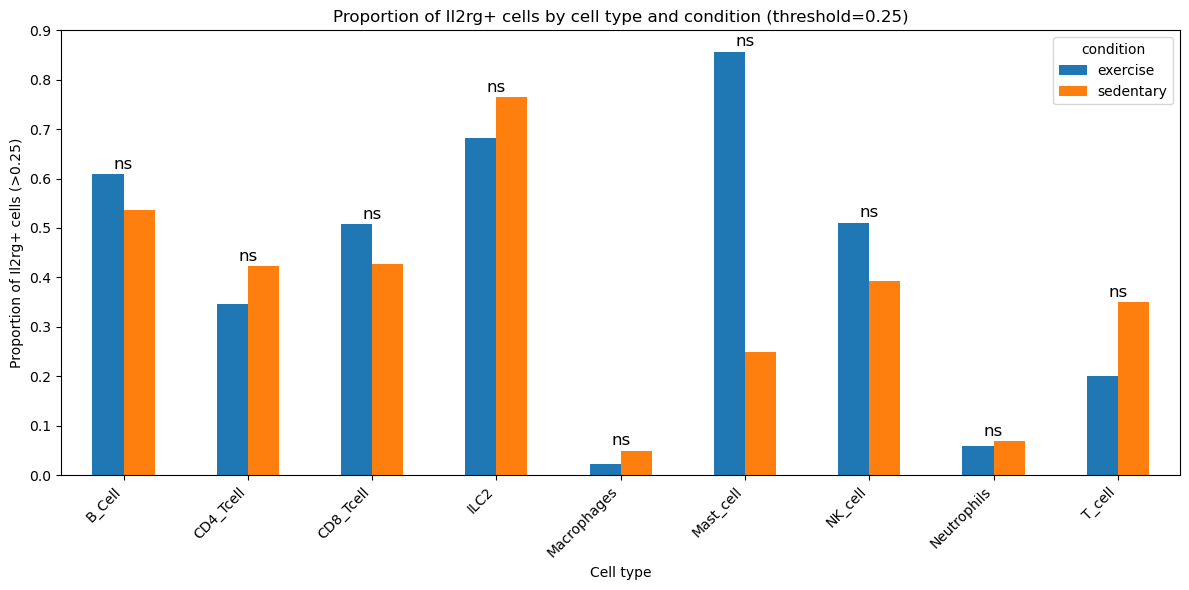

In [37]:
threshold = 0.25 # you can test 0.25, 0.5 as well

df = pd.DataFrame({
    "Il2rg": adata_immune[:, ["Il2rg"]].X.toarray().flatten(),
    "celltype": adata_immune.obs["celltype"].values,
    "condition": adata_immune.obs["condition"].values
})

df["Il2rg_pos"] = df["Il2rg"] > threshold

prop_table = df.groupby(["celltype", "condition"])["Il2rg_pos"].mean().unstack()
celltypes = prop_table.index.tolist()

pvals = []

for ct in celltypes:
    sub = df[df["celltype"] == ct]

    ex = sub[sub["condition"] == "exercise"]["Il2rg_pos"]
    sed = sub[sub["condition"] == "sedentary"]["Il2rg_pos"]

    table = np.array([
        [ex.sum(), (~ex).sum()],
        [sed.sum(), (~sed).sum()]
    ])

    if table.shape == (2, 2):
        _, p = fisher_exact(table)
    else:
        p = np.nan

    pvals.append(p)

valid_mask = ~np.isnan(pvals)
padj = np.full(len(pvals), np.nan)
padj[valid_mask] = multipletests(np.array(pvals)[valid_mask], method="fdr_bh")[1]

stats_df = pd.DataFrame({
    "celltype": celltypes,
    "pval": pvals,
    "padj": padj
}).set_index("celltype")

def p_to_star(p):
    if pd.isna(p):
        return "na"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

stats_df["sig"] = stats_df["padj"].apply(p_to_star)

results = prop_table.join(stats_df)
print(results)

ax = prop_table[["exercise", "sedentary"]].plot(kind="bar", figsize=(12, 6))
plt.ylabel(f"Proportion of Il2rg+ cells (>{threshold})")
plt.xlabel("Cell type")
plt.title(f"Proportion of Il2rg+ cells by cell type and condition (threshold={threshold})")
plt.xticks(rotation=45, ha="right")

ymax = prop_table.max(axis=1)
offset = ymax.max() * 0.005

for i, ct in enumerate(prop_table.index):
    ax.text(i, ymax.loc[ct] + offset, results.loc[ct, "sig"],
            ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.show()